# Create AFNI 3dLMEr data table

## Functions

### Summarize data table

In [1]:
def summarize_dataframe(df, name="DataFrame"):
    """
    Generate comprehensive summary statistics for a dataframe.
    
    Parameters:
    -----------
    df : pd.DataFrame
        The dataframe to summarize
    name : str
        Name of the dataframe for display purposes
        
    Returns:
    --------
    tuple : (col_info, desc_stats)
        col_info: DataFrame with column-level information
        desc_stats: DataFrame with descriptive statistics
    """
    print(f"\n{'='*50}")
    print(f"Summary for: {name}")
    print(f"{'='*50}\n")
    
    # Show summary info
    df.info(verbose=True, show_counts=True)
    
    # Per-column summary table
    col_info = pd.DataFrame({
        'dtype': df.dtypes.astype(str),
        'non_null': df.count(),
        'n_unique(incl_NaN)': df.nunique(dropna=False),
        'pct_missing': (df.isna().mean() * 100).round(2),
        'sample_values_first5': df.apply(lambda s: s.dropna().unique()[:5].tolist())
    })
    
    # Descriptive statistics
    desc_stats = df.describe(include='all').T
    
    return col_info, desc_stats

# Usage example:
# merged_col_info, merged_desc_all = summarize_dataframe(merged_df, "merged_df")

## Load relevant modules|

In [2]:
# Old Windows WSL paths (kept as reference)
# participants_input_path = r"\\wsl.localhost\Ubuntu\home\gagpat01\mes_projets\maitrise\Behavioral\data\participants_gb.tsv"
# data_table_format_input_path = r"\\wsl.localhost\Ubuntu\home\gagpat01\mes_projets\maitrise\fmri\data\LME_longitudinal_datatable.txt"
# output_path = r"\\wsl.localhost\Ubuntu\home\gagpat01\mes_projets\maitrise\fmri\results\3dlmerdata_table_with_covariates.txt"


# Define input file paths using local Linux paths
# participants_gb.tsv contains demographic and clinical data for all participants
participants_input_path = "~/Documents/GutBrain/data/participants_gb.tsv"

# 3dLMEr_table.txt is the template data table with fMRI file paths and basic structure
data_table_format_input_path = "~/Documents/GutBrain/BIDS_results/3dLmer/3dLMEr_table.txt"

# qc_final_decision_clean.csv contains quality control decisions for excluding bad scans
qc_decision_path = "~/Documents/GutBrain/derivatives7/qc_final_decision_clean.csv"

# Output path not set yet - will be defined later when saving results
# output_path = "~/Documents/GutBrain/BIDS_results/3dLmer/3dlmerdata_table_with_covariates.txt"

In [3]:
import pandas as pd
import os

# Load QC decision file
qc_decision_path_expanded = os.path.expanduser(qc_decision_path)
qc_df = pd.read_csv(qc_decision_path_expanded)

# Show comprehensive summary
print("=" * 80)
print("QC DECISION FILE SUMMARY")
print("=" * 80)

# Basic info
print(f"\nTotal rows: {len(qc_df)}")
print(f"Total columns: {len(qc_df.columns)}")

# Show all column names
print("\n" + "=" * 80)
print("COLUMN NAMES:")
print("=" * 80)
print(qc_df.columns.tolist())

# Key QC columns summary
print("\n" + "=" * 80)
print("KEY QC DECISION COLUMNS:")
print("=" * 80)

# BIDS name breakdown
print(f"\nUnique BIDS names (sub-sess-run combos): {qc_df['bids_name'].nunique()}")
print(f"Sample BIDS names:\n{qc_df['bids_name'].head(10).tolist()}")

# Decision column
if 'Decision finale' in qc_df.columns:
    print(f"\nDecision finale value counts:")
    print(qc_df['Decision finale'].value_counts())
    
if 'decision' in qc_df.columns:
    print(f"\nDecision (intermediate) value counts:")
    print(qc_df['decision'].value_counts())

# Session breakdown
if 'Session' in qc_df.columns:
    print(f"\nSession distribution:")
    print(qc_df['Session'].value_counts().sort_index())

# Check for exclusion reasons
if 'Commentaire final' in qc_df.columns:
    print(f"\nExclusion comments (non-empty):")
    print(qc_df[qc_df['Commentaire final'].notna()]['Commentaire final'].value_counts())

# Descriptive statistics for QC metrics
print("\n" + "=" * 80)
print("QC METRICS SUMMARY:")
print("=" * 80)
qc_metrics = ['fd_mean', 'fd_max', 'fd_num', 'fd_num_above_3mm', 'dvars_nstd', 
              'tsnr', 'Coverage_percentage']
available_metrics = [m for m in qc_metrics if m in qc_df.columns]
print(qc_df[available_metrics].describe())

# Detailed column info
print("\n" + "=" * 80)
print("DETAILED COLUMN INFORMATION:")
print("=" * 80)
qc_col_info = pd.DataFrame({
    'dtype': qc_df.dtypes.astype(str),
    'non_null': qc_df.count(),
    'n_unique': qc_df.nunique(),
    'pct_missing': (qc_df.isna().mean() * 100).round(2),
    'sample_values': qc_df.apply(lambda s: s.dropna().unique()[:3].tolist())
})
print(qc_col_info)

# Show first few rows
print("\n" + "=" * 80)
print("FIRST 5 ROWS:")
print("=" * 80)
print(qc_df.head())

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Patrick/Documents/GutBrain/derivatives7/qc_final_decision_clean.csv'

In [ ]:
import pandas as pd
import re
import os

# Define the conversion function first
def from_afni_id(x):
    """Convert 'sub-RCX096' → 'rcx096', 'sub-RND001' → 'rnd001'"""
    m = re.match(r"sub-([A-Z]+)(\d+)", x)
    if m:
        prefix = m.group(1).lower()
        number = m.group(2).zfill(3)
        return f"{prefix}{number}"
    return x

# Load QC decision file
qc_decision_path_expanded = os.path.expanduser(qc_decision_path)
qc_df = pd.read_csv(qc_decision_path_expanded)

# Parse bids_name to extract subject, session, and run
def parse_bids_name(bids_name):
    """
    Parse BIDS name like 'sub-RCX097_ses-1_task-BDM_run-1_bold'
    Returns dict with subject, session, run
    """
    # Extract subject (e.g., 'sub-RCX097' -> 'rcx097')
    subj_match = re.search(r'sub-([A-Z]+\d+)', bids_name)
    subj = subj_match.group(1).lower() if subj_match else None
    
    # Extract session (e.g., 'ses-1' -> 1)
    sess_match = re.search(r'ses-(\d+)', bids_name)
    sess = int(sess_match.group(1)) if sess_match else None
    
    # Extract run (e.g., 'run-1' -> 1)
    run_match = re.search(r'run-(\d+)', bids_name)
    run = int(run_match.group(1)) if run_match else None
    
    return {'Subj': subj, 'sess': sess, 'run': run}

# Parse all bids_name entries
qc_parsed = qc_df['bids_name'].apply(parse_bids_name).apply(pd.Series)
qc_df_with_parsed = pd.concat([qc_df, qc_parsed], axis=1)

# Clean up the decision column by stripping whitespace
if 'Decision finale' in qc_df_with_parsed.columns:
    qc_df_with_parsed['Decision finale'] = qc_df_with_parsed['Decision finale'].astype(str).str.strip()
    approved_scans = qc_df_with_parsed[qc_df_with_parsed['Decision finale'] == 'inclure'].copy()
    print(f"Using 'Decision finale' column with value 'inclure'")
elif 'decision' in qc_df_with_parsed.columns:
    qc_df_with_parsed['decision'] = qc_df_with_parsed['decision'].astype(str).str.strip()
    approved_scans = qc_df_with_parsed[qc_df_with_parsed['decision'] == 'include'].copy()
    print(f"Using 'decision' column with value 'include'")
else:
    print("ERROR: No decision column found!")
    approved_scans = qc_df_with_parsed.copy()

print(f"\nTotal scans in QC file: {len(qc_df_with_parsed)}")
print(f"Approved scans: {len(approved_scans)}")
print(f"Excluded scans: {len(qc_df_with_parsed) - len(approved_scans)}")

# Create base dataframe with only Subj, sess, run from approved QC scans
base_df = approved_scans[['Subj', 'sess', 'run']].copy()

# Load and prepare participants_df
print("Loading participants_df...")
participants_df = pd.read_csv(os.path.expanduser(participants_input_path), sep='\t')
participants_df = participants_df.rename(columns={'participant_id': 'Subj', 'session': 'sess'})
participants_df['Subj'] = participants_df['Subj'].astype(str).apply(from_afni_id)
participants_df['sess'] = pd.to_numeric(participants_df['sess'], errors='coerce')

# Fix handedness for rcx247 and rnd076
if 'handedness' in participants_df.columns:
    participants_df.loc[participants_df['Subj'] == 'rcx247', 'handedness'] = 'right'
    participants_df.loc[participants_df['Subj'] == 'rnd076', 'handedness'] = 'right'
    print("\nFixed handedness for rcx247 and rnd076 to 'right'")

# Merge with participants data
merged_df = pd.merge(
    base_df,
    participants_df,
    how='left',
    on=['Subj', 'sess'],
    suffixes=('', '_part')
)

# Drop unwanted columns (including TWL)
cols_to_drop = [col.strip() for col in [
    'weight', 'imc_recherche', 'ewl_recherche', 'twl_recherche',
    'bi_ttaille', 'bi_thanche', 'bi_tcou',
    'tx_t2d___3', 'qte_boost', 'tx_t2d___2', 'age', 'vas_fin', 't2d', ' tx_t2d___1',
    'twl_24months'  # Remove TWL@24months if it exists
]]
merged_df = merged_df.drop(columns=[col for col in cols_to_drop if col in merged_df.columns])

# Grand mean center selected columns
for col in ['vas_debut', 'age_baseline', 'bmi_baseline']:
    if col in merged_df.columns:
        merged_df[col] = merged_df[col] - merged_df[col].mean()

# Convert sess, type_chx, and run to string for categorical treatment in AFNI
for col in ['sess', 'type_chx', 'run']:
    if col in merged_df.columns:
        merged_df[col] = merged_df[col].astype(int).astype(str)

# Impute missing values by mean within each session
numeric_cols = merged_df.select_dtypes(include='number').columns
participant_col = 'id_participant' if 'id_participant' in merged_df.columns else 'Subj'

for col in numeric_cols:
    session_means = merged_df.groupby('sess')[col].transform('mean')
    imputed_mask = merged_df[col].isna() & session_means.notna()

    if imputed_mask.any():
        for _, row in merged_df.loc[imputed_mask, [participant_col, 'sess']].iterrows():
            print(f"Imputed column='{col}' for {participant_col}='{row[participant_col]}', session='{row['sess']}'")

    merged_df[col] = merged_df[col].fillna(session_means)

print(f"\n{'='*80}")
print("FINAL MERGED DATAFRAME SUMMARY:")
print(f"{'='*80}")
print(f"Total rows: {len(merged_df)}")
print(f"Unique subjects: {merged_df['Subj'].nunique()}")
print(f"Unique sessions: {merged_df['sess'].nunique()}")
print(f"\nScans per session:")
print(merged_df['sess'].value_counts().sort_index())

# Check handedness
if 'handedness' in merged_df.columns:
    print(f"\nHandedness distribution:")
    print(merged_df[['Subj', 'handedness']].drop_duplicates().groupby('handedness').size())
    print(f"\nrcx247 handedness: {merged_df[merged_df['Subj'] == 'rcx247']['handedness'].unique()}")
    print(f"rnd076 handedness: {merged_df[merged_df['Subj'] == 'rnd076']['handedness'].unique()}")

# Display first few rows
merged_df.head()

Using 'Decision finale' column with value 'inclure'

Total scans in QC file: 507
Approved scans: 507
Excluded scans: 0
Loading participants_df...

Fixed handedness for rcx247 and rnd076 to 'right'

FINAL MERGED DATAFRAME SUMMARY:
Total rows: 507
Unique subjects: 57
Unique sessions: 4

Scans per session:
sess
1    146
2    138
3    112
4    111
Name: count, dtype: int64

Handedness distribution:
handedness
left      3
right    54
dtype: int64

rcx247 handedness: ['right']
rnd076 handedness: ['right']


,Subj,sess,run,sex,type_chx,handedness,vas_debut,age_baseline,bmi_baseline
0,rcx097,1,1,female,3,right,0.073987,-4.134714,0.107199
1,rcx097,1,2,female,3,right,0.073987,-4.134714,0.107199
2,rcx097,2,1,female,3,right,-3.162124,-4.134714,0.107199
3,rcx097,2,2,female,3,right,-3.162124,-4.134714,0.107199
4,rcx097,2,3,female,3,right,-3.162124,-4.134714,0.107199


In [16]:
# Define output path for the data tables
import os

# Set the output directory and base filename
output_dir = os.path.expanduser("~/Documents/GutBrain/BIDS_results/3dLmer")
base_filename = "3dlmerdata_table_with_covariates_qc_final.txt"

# Create the full output path
output_path = os.path.join(output_dir, base_filename)

# Create directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

print(f"Output path set to: {output_path}")

Output path set to: /home/gagpat01/Documents/GutBrain/BIDS_results/3dLmer/3dlmerdata_table_with_covariates_qc_final.txt


In [17]:
# --- Create data table for view_Hi_vs_view_low_v7_literature_complex_psc ---

def make_view_Hi_vs_view_low_v7_literature_complex_psc_inputfile(row):
    subj = str(row['Subj']).upper()
    sess = str(row['sess'])
    run = str(row['run'])
    return f"/home/pagag24/projects/def-amichaud/share/GutBrain/BIDS_results2/sub-{subj}/ses-{sess}/func/sub-{subj}_ses-{sess}_run-{run}_effect-size_v7_literature_complex_view_Hi_vs_view_low_v7_literature_complex_psc.nii.gz"

# Create a new table with the same rows but new InputFile paths
view_Hi_vs_view_low_v7_literature_complex_psc_table = merged_df.copy()
view_Hi_vs_view_low_v7_literature_complex_psc_table['InputFile'] = view_Hi_vs_view_low_v7_literature_complex_psc_table.apply(
    make_view_Hi_vs_view_low_v7_literature_complex_psc_inputfile, axis=1
)

# Save to a new file with qc_final suffix at the end
output_path_view_Hi_vs_view_low_v7_literature_complex_psc = output_path.replace(
    '_qc_final.txt', '_view_Hi_vs_view_low_v7_literature_complex_psc_qc_final.txt'
)
view_Hi_vs_view_low_v7_literature_complex_psc_table.to_csv(
    output_path_view_Hi_vs_view_low_v7_literature_complex_psc, sep='\t', index=False, lineterminator='\n'
)

print(f"New table with view_Hi_vs_view_low_v7_literature_complex_psc InputFile column saved to: {output_path_view_Hi_vs_view_low_v7_literature_complex_psc}")

# --- Create data table for mod_hi_vs_mod_lo_v7_literature_complex_psc ---

def make_mod_hi_vs_mod_lo_v7_literature_complex_psc_inputfile(row):
    subj = str(row['Subj']).upper()
    sess = str(row['sess'])
    run = str(row['run'])
    return f"/home/pagag24/projects/def-amichaud/share/GutBrain/BIDS_results2/sub-{subj}/ses-{sess}/func/sub-{subj}_ses-{sess}_run-{run}_effect-size_v7_literature_complex_mod_hi_vs_mod_lo_v7_literature_complex_psc.nii.gz"

# Create a new table with the same rows but new InputFile paths
mod_hi_vs_mod_lo_v7_literature_complex_psc_table = merged_df.copy()
mod_hi_vs_mod_lo_v7_literature_complex_psc_table['InputFile'] = mod_hi_vs_mod_lo_v7_literature_complex_psc_table.apply(make_mod_hi_vs_mod_lo_v7_literature_complex_psc_inputfile, axis=1)

# Save to a new file with qc_final suffix at the end
output_path_mod_hi_vs_mod_lo_v7_literature_complex_psc = output_path.replace('_qc_final.txt', '_mod_hi_vs_mod_lo_v7_literature_complex_psc_qc_final.txt')
mod_hi_vs_mod_lo_v7_literature_complex_psc_table.to_csv(output_path_mod_hi_vs_mod_lo_v7_literature_complex_psc, sep='\t', index=False, lineterminator='\n')

print(f"New table with mod_hi_vs_mod_lo_v7_literature_complex_psc InputFile column saved to: {output_path_mod_hi_vs_mod_lo_v7_literature_complex_psc}")

# --- Create data table for v7_literature_complex_mod_view_Lo_vs_0_psc ---

def make_v7_literature_complex_mod_view_Lo_vs_0_psc_inputfile(row):
    subj = str(row['Subj']).upper()
    sess = str(row['sess'])
    run = str(row['run'])
    return f"/home/pagag24/projects/def-amichaud/share/GutBrain/BIDS_results2/sub-{subj}/ses-{sess}/func/sub-{subj}_ses-{sess}_run-{run}_effect-size_v7_literature_complex_mod_view_Lo_vs_0_psc.nii.gz"

# Create a new table with the same rows but new InputFile paths
v7_literature_complex_mod_view_Lo_vs_0_psc_table = merged_df.copy()
v7_literature_complex_mod_view_Lo_vs_0_psc_table['InputFile'] = v7_literature_complex_mod_view_Lo_vs_0_psc_table.apply(
    make_v7_literature_complex_mod_view_Lo_vs_0_psc_inputfile, axis=1
)

# Save to a new file with qc_final suffix at the end
output_path_v7_literature_complex_mod_view_Lo_vs_0_psc = output_path.replace(
    '_qc_final.txt', '_v7_literature_complex_mod_view_Lo_vs_0_psc_qc_final.txt'
)
v7_literature_complex_mod_view_Lo_vs_0_psc_table.to_csv(
    output_path_v7_literature_complex_mod_view_Lo_vs_0_psc, sep='\t', index=False, lineterminator='\n'
)

print(f"New table with v7_literature_complex_mod_view_Lo_vs_0_psc InputFile column saved to: {output_path_v7_literature_complex_mod_view_Lo_vs_0_psc}")

# --- Create data table for v7_literature_complex_mod_view_Hi_vs_0_psc ---

def make_v7_literature_complex_mod_view_Hi_vs_0_psc_inputfile(row):
    subj = str(row['Subj']).upper()
    sess = str(row['sess'])
    run = str(row['run'])
    return f"/home/pagag24/projects/def-amichaud/share/GutBrain/BIDS_results2/sub-{subj}/ses-{sess}/func/sub-{subj}_ses-{sess}_run-{run}_effect-size_v7_literature_complex_mod_view_Hi_vs_0_psc.nii.gz"

# Create a new table with the same rows but new InputFile paths
v7_literature_complex_mod_view_Hi_vs_0_psc_table = merged_df.copy()
v7_literature_complex_mod_view_Hi_vs_0_psc_table['InputFile'] = v7_literature_complex_mod_view_Hi_vs_0_psc_table.apply(
    make_v7_literature_complex_mod_view_Hi_vs_0_psc_inputfile, axis=1
)

# Save to a new file with qc_final suffix at the end
output_path_v7_literature_complex_mod_view_Hi_vs_0_psc = output_path.replace(
    '_qc_final.txt', '_v7_literature_complex_mod_view_Hi_vs_0_psc_qc_final.txt'
)
v7_literature_complex_mod_view_Hi_vs_0_psc_table.to_csv(
    output_path_v7_literature_complex_mod_view_Hi_vs_0_psc, sep='\t', index=False, lineterminator='\n'
)

print(f"New table with v7_literature_complex_mod_view_Hi_vs_0_psc InputFile column saved to: {output_path_v7_literature_complex_mod_view_Hi_vs_0_psc}")

New table with view_Hi_vs_view_low_v7_literature_complex_psc InputFile column saved to: /home/gagpat01/Documents/GutBrain/BIDS_results/3dLmer/3dlmerdata_table_with_covariates_view_Hi_vs_view_low_v7_literature_complex_psc_qc_final.txt
New table with mod_hi_vs_mod_lo_v7_literature_complex_psc InputFile column saved to: /home/gagpat01/Documents/GutBrain/BIDS_results/3dLmer/3dlmerdata_table_with_covariates_mod_hi_vs_mod_lo_v7_literature_complex_psc_qc_final.txt
New table with v7_literature_complex_mod_view_Lo_vs_0_psc InputFile column saved to: /home/gagpat01/Documents/GutBrain/BIDS_results/3dLmer/3dlmerdata_table_with_covariates_v7_literature_complex_mod_view_Lo_vs_0_psc_qc_final.txt
New table with v7_literature_complex_mod_view_Hi_vs_0_psc InputFile column saved to: /home/gagpat01/Documents/GutBrain/BIDS_results/3dLmer/3dlmerdata_table_with_covariates_v7_literature_complex_mod_view_Hi_vs_0_psc_qc_final.txt


## Make data tables withouth participants-sessions that have only 1 run per sessions

In [18]:
# ============================================================
# CREATE DATA TABLES WITH MULTI-RUN THRESHOLD (mr_th_1_ru)
# ============================================================

print("="*80)
print("CREATING DATA TABLES WITH MULTI-RUN FILTERING")
print("="*80)

# Filter to keep only participant-sessions with MORE than 1 run
def filter_multirun(df):
    """Filter dataframe to keep only participant-sessions with >1 run"""
    runs_per_session = df.groupby(['Subj', 'sess'])['run'].transform('count')
    return df[runs_per_session > 1].copy()

# Apply multi-run filter to merged_df
merged_df_mr = filter_multirun(merged_df)

# Create dataframe of EXCLUDED rows (those with only 1 run per session)
runs_per_session = merged_df.groupby(['Subj', 'sess'])['run'].transform('count')
merged_df_excluded = merged_df[runs_per_session == 1].copy()

# Diagnostics
rows_before = len(merged_df)
rows_after = len(merged_df_mr)
rows_discarded = len(merged_df_excluded)

print(f"\nMulti-run filtering results:")
print(f"  Rows before filtering: {rows_before}")
print(f"  Rows after filtering: {rows_after}")
print(f"  Rows discarded: {rows_discarded} ({rows_discarded/rows_before*100:.1f}%)")

# Count participant-sessions discarded
sessions_before = merged_df.groupby(['Subj', 'sess']).size()
sessions_after = merged_df_mr.groupby(['Subj', 'sess']).size()
sessions_excluded = merged_df_excluded.groupby(['Subj', 'sess']).size()
sessions_discarded = len(sessions_before) - len(sessions_after)

print(f"\n  Participant-sessions before: {len(sessions_before)}")
print(f"  Participant-sessions after: {len(sessions_after)}")
print(f"  Participant-sessions discarded: {sessions_discarded}")

# Count unique participants per session
print(f"\n{'='*80}")
print("UNIQUE PARTICIPANTS PER SESSION")
print(f"{'='*80}")

print(f"\nBEFORE multi-run filtering:")
participants_per_session_before = merged_df.groupby('sess')['Subj'].nunique().sort_index()
for sess, count in participants_per_session_before.items():
    print(f"  Session {sess}: {count} unique participants")
print(f"  Total unique participants (across all sessions): {merged_df['Subj'].nunique()}")

print(f"\nAFTER multi-run filtering:")
participants_per_session_after = merged_df_mr.groupby('sess')['Subj'].nunique().sort_index()
for sess, count in participants_per_session_after.items():
    participants_lost = participants_per_session_before[sess] - count
    print(f"  Session {sess}: {count} unique participants (lost {participants_lost})")
print(f"  Total unique participants (across all sessions): {merged_df_mr['Subj'].nunique()}")

print(f"\nEXCLUDED (single-run sessions):")
participants_per_session_excluded = merged_df_excluded.groupby('sess')['Subj'].nunique().sort_index()
for sess, count in participants_per_session_excluded.items():
    print(f"  Session {sess}: {count} unique participants")
print(f"  Total unique participants excluded: {merged_df_excluded['Subj'].nunique()}")

# Show distribution of runs per session
print(f"\n{'='*80}")
print("RUNS PER PARTICIPANT-SESSION DISTRIBUTION")
print(f"{'='*80}")

print(f"\nBEFORE filtering:")
print(merged_df.groupby(['Subj', 'sess']).size().value_counts().sort_index())

print(f"\nAFTER filtering (kept):")
print(merged_df_mr.groupby(['Subj', 'sess']).size().value_counts().sort_index())

print(f"\nEXCLUDED (single-run only):")
print(merged_df_excluded.groupby(['Subj', 'sess']).size().value_counts().sort_index())

# Save filtered dataframe (KEPT) for QC
output_path_mr_kept = output_path.replace('_qc_final.txt', '_mr_th_1_ru_qc_final.txt')
merged_df_mr.to_csv(output_path_mr_kept, sep='\t', index=False, lineterminator='\n')

# Save excluded dataframe (DISCARDED) for QC
output_path_mr_excluded = output_path.replace('_qc_final.txt', '_mr_th_1_ru_EXCLUDED_qc_final.txt')
merged_df_excluded.to_csv(output_path_mr_excluded, sep='\t', index=False, lineterminator='\n')

print(f"\n{'='*80}")
print("DATA TABLES SAVED FOR QC")
print(f"{'='*80}")

print(f"\nKEPT (multi-run sessions):")
print(f"  File: {output_path_mr_kept}")
print(f"  Rows: {len(merged_df_mr)}")
print(f"  Unique subjects: {merged_df_mr['Subj'].nunique()}")

print(f"\nEXCLUDED (single-run sessions):")
print(f"  File: {output_path_mr_excluded}")
print(f"  Rows: {len(merged_df_excluded)}")
print(f"  Unique subjects: {merged_df_excluded['Subj'].nunique()}")
print(f"  These participant-sessions had only 1 run and were filtered out")

print("\n" + "="*80)

CREATING DATA TABLES WITH MULTI-RUN FILTERING

Multi-run filtering results:
  Rows before filtering: 507
  Rows after filtering: 481
  Rows discarded: 26 (5.1%)

  Participant-sessions before: 199
  Participant-sessions after: 173
  Participant-sessions discarded: 26

UNIQUE PARTICIPANTS PER SESSION

BEFORE multi-run filtering:
  Session 1: 57 unique participants
  Session 2: 52 unique participants
  Session 3: 46 unique participants
  Session 4: 44 unique participants
  Total unique participants (across all sessions): 57

AFTER multi-run filtering:
  Session 1: 50 unique participants (lost 7)
  Session 2: 47 unique participants (lost 5)
  Session 3: 36 unique participants (lost 10)
  Session 4: 40 unique participants (lost 4)
  Total unique participants (across all sessions): 56

EXCLUDED (single-run sessions):
  Session 1: 7 unique participants
  Session 2: 5 unique participants
  Session 3: 10 unique participants
  Session 4: 4 unique participants
  Total unique participants exclude

In [19]:
# ============================================================
# CREATE DATA TABLES WITH MULTI-RUN FILTERING (mr_th_1_ru)
# ============================================================

print("="*80)
print("CREATING DATA TABLES WITH MULTI-RUN SUFFIX (_mr_th_1_ru)")
print("="*80)

# --- Create data table for view_Hi_vs_view_low_v7_literature_complex_psc ---

def make_view_Hi_vs_view_low_v7_literature_complex_psc_inputfile(row):
    subj = str(row['Subj']).upper()
    sess = str(row['sess'])
    run = str(row['run'])
    return f"/home/pagag24/projects/def-amichaud/share/GutBrain/BIDS_results2/sub-{subj}/ses-{sess}/func/sub-{subj}_ses-{sess}_run-{run}_effect-size_v7_literature_complex_view_Hi_vs_view_low_v7_literature_complex_psc.nii.gz"

view_Hi_vs_view_low_v7_literature_complex_psc_mr_table = merged_df_mr.copy()
view_Hi_vs_view_low_v7_literature_complex_psc_mr_table['InputFile'] = view_Hi_vs_view_low_v7_literature_complex_psc_mr_table.apply(
    make_view_Hi_vs_view_low_v7_literature_complex_psc_inputfile, axis=1
)

output_path_view_Hi_vs_view_low_v7_literature_complex_psc_mr = output_path.replace(
    '_qc_final.txt', '_view_Hi_vs_view_low_v7_literature_complex_psc_mr_th_1_ru_qc_final.txt'
)
view_Hi_vs_view_low_v7_literature_complex_psc_mr_table.to_csv(
    output_path_view_Hi_vs_view_low_v7_literature_complex_psc_mr, sep='\t', index=False, lineterminator='\n'
)

print(f"✓ view_Hi_vs_view_low_v7_literature_complex_psc (multi-run) saved to:")
print(f"  {output_path_view_Hi_vs_view_low_v7_literature_complex_psc_mr}")

# --- Create data table for mod_hi_vs_mod_lo_v7_literature_complex_psc ---

def make_mod_hi_vs_mod_lo_v7_literature_complex_psc_inputfile(row):
    subj = str(row['Subj']).upper()
    sess = str(row['sess'])
    run = str(row['run'])
    return f"/home/pagag24/projects/def-amichaud/share/GutBrain/BIDS_results2/sub-{subj}/ses-{sess}/func/sub-{subj}_ses-{sess}_run-{run}_effect-size_v7_literature_complex_mod_hi_vs_mod_lo_v7_literature_complex_psc.nii.gz"

mod_hi_vs_mod_lo_v7_literature_complex_psc_mr_table = merged_df_mr.copy()
mod_hi_vs_mod_lo_v7_literature_complex_psc_mr_table['InputFile'] = mod_hi_vs_mod_lo_v7_literature_complex_psc_mr_table.apply(
    make_mod_hi_vs_mod_lo_v7_literature_complex_psc_inputfile, axis=1
)

output_path_mod_hi_vs_mod_lo_v7_literature_complex_psc_mr = output_path.replace(
    '_qc_final.txt', '_mod_hi_vs_mod_lo_v7_literature_complex_psc_mr_th_1_ru_qc_final.txt'
)
mod_hi_vs_mod_lo_v7_literature_complex_psc_mr_table.to_csv(
    output_path_mod_hi_vs_mod_lo_v7_literature_complex_psc_mr, sep='\t', index=False, lineterminator='\n'
)

print(f"✓ mod_hi_vs_mod_lo_v7_literature_complex_psc (multi-run) saved to:")
print(f"  {output_path_mod_hi_vs_mod_lo_v7_literature_complex_psc_mr}")

# --- Create data table for v7_literature_complex_mod_view_Lo_vs_0_psc ---

def make_v7_literature_complex_mod_view_Lo_vs_0_psc_inputfile(row):
    subj = str(row['Subj']).upper()
    sess = str(row['sess'])
    run = str(row['run'])
    return f"/home/pagag24/projects/def-amichaud/share/GutBrain/BIDS_results2/sub-{subj}/ses-{sess}/func/sub-{subj}_ses-{sess}_run-{run}_effect-size_v7_literature_complex_mod_view_Lo_vs_0_psc.nii.gz"

v7_literature_complex_mod_view_Lo_vs_0_psc_mr_table = merged_df_mr.copy()
v7_literature_complex_mod_view_Lo_vs_0_psc_mr_table['InputFile'] = v7_literature_complex_mod_view_Lo_vs_0_psc_mr_table.apply(
    make_v7_literature_complex_mod_view_Lo_vs_0_psc_inputfile, axis=1
)

output_path_v7_literature_complex_mod_view_Lo_vs_0_psc_mr = output_path.replace(
    '_qc_final.txt', '_v7_literature_complex_mod_view_Lo_vs_0_psc_mr_th_1_ru_qc_final.txt'
)
v7_literature_complex_mod_view_Lo_vs_0_psc_mr_table.to_csv(
    output_path_v7_literature_complex_mod_view_Lo_vs_0_psc_mr, sep='\t', index=False, lineterminator='\n'
)

print(f"✓ v7_literature_complex_mod_view_Lo_vs_0_psc (multi-run) saved to:")
print(f"  {output_path_v7_literature_complex_mod_view_Lo_vs_0_psc_mr}")

# --- Create data table for v7_literature_complex_mod_view_Hi_vs_0_psc ---

def make_v7_literature_complex_mod_view_Hi_vs_0_psc_inputfile(row):
    subj = str(row['Subj']).upper()
    sess = str(row['sess'])
    run = str(row['run'])
    return f"/home/pagag24/projects/def-amichaud/share/GutBrain/BIDS_results2/sub-{subj}/ses-{sess}/func/sub-{subj}_ses-{sess}_run-{run}_effect-size_v7_literature_complex_mod_view_Hi_vs_0_psc.nii.gz"

v7_literature_complex_mod_view_Hi_vs_0_psc_mr_table = merged_df_mr.copy()
v7_literature_complex_mod_view_Hi_vs_0_psc_mr_table['InputFile'] = v7_literature_complex_mod_view_Hi_vs_0_psc_mr_table.apply(
    make_v7_literature_complex_mod_view_Hi_vs_0_psc_inputfile, axis=1
)

output_path_v7_literature_complex_mod_view_Hi_vs_0_psc_mr = output_path.replace(
    '_qc_final.txt', '_v7_literature_complex_mod_view_Hi_vs_0_psc_mr_th_1_ru_qc_final.txt'
)
v7_literature_complex_mod_view_Hi_vs_0_psc_mr_table.to_csv(
    output_path_v7_literature_complex_mod_view_Hi_vs_0_psc_mr, sep='\t', index=False, lineterminator='\n'
)

print(f"✓ v7_literature_complex_mod_view_Hi_vs_0_psc (multi-run) saved to:")
print(f"  {output_path_v7_literature_complex_mod_view_Hi_vs_0_psc_mr}")

# Summary
print("\n" + "="*80)
print("SUMMARY: MULTI-RUN FILTERED DATA TABLES")
print("="*80)
print(f"Total tables created: 4")
print(f"All tables use multi-run filtered data (>1 run per session)")
print(f"Total rows in each table: {len(merged_df_mr)}")
print(f"Unique subjects: {merged_df_mr['Subj'].nunique()}")
print(f"Unique sessions: {merged_df_mr['sess'].nunique()}")
print(f"\nAll output filenames have '_mr_th_1_ru_qc_final.txt' suffix")
print("="*80)

CREATING DATA TABLES WITH MULTI-RUN SUFFIX (_mr_th_1_ru)
✓ view_Hi_vs_view_low_v7_literature_complex_psc (multi-run) saved to:
  /home/gagpat01/Documents/GutBrain/BIDS_results/3dLmer/3dlmerdata_table_with_covariates_view_Hi_vs_view_low_v7_literature_complex_psc_mr_th_1_ru_qc_final.txt
✓ mod_hi_vs_mod_lo_v7_literature_complex_psc (multi-run) saved to:
  /home/gagpat01/Documents/GutBrain/BIDS_results/3dLmer/3dlmerdata_table_with_covariates_mod_hi_vs_mod_lo_v7_literature_complex_psc_mr_th_1_ru_qc_final.txt
✓ v7_literature_complex_mod_view_Lo_vs_0_psc (multi-run) saved to:
  /home/gagpat01/Documents/GutBrain/BIDS_results/3dLmer/3dlmerdata_table_with_covariates_v7_literature_complex_mod_view_Lo_vs_0_psc_mr_th_1_ru_qc_final.txt
✓ v7_literature_complex_mod_view_Hi_vs_0_psc (multi-run) saved to:
  /home/gagpat01/Documents/GutBrain/BIDS_results/3dLmer/3dlmerdata_table_with_covariates_v7_literature_complex_mod_view_Hi_vs_0_psc_mr_th_1_ru_qc_final.txt

SUMMARY: MULTI-RUN FILTERED DATA TABLES
Tota

## diagnose missing rows in final data tables

In [20]:
# --- Create data table for mod_hi_vs_mod_lo_v7_literature_complex_psc ---

def make_mod_hi_vs_mod_lo_v7_literature_complex_psc_inputfile(row):
    subj = str(row['Subj']).upper()
    sess = str(row['sess'])
    run = str(row['run'])
    return f"/home/pagag24/projects/def-amichaud/share/GutBrain/BIDS_results2/sub-{subj}/ses-{sess}/func/sub-{subj}_ses-{sess}_run-{run}_effect-size_v7_literature_complex_mod_hi_vs_mod_lo_v7_literature_complex_psc.nii.gz"

# Create a new table with the same rows but new InputFile paths
mod_hi_vs_mod_lo_v7_literature_complex_psc_table = merged_df.copy()
mod_hi_vs_mod_lo_v7_literature_complex_psc_table['InputFile'] = mod_hi_vs_mod_lo_v7_literature_complex_psc_table.apply(make_mod_hi_vs_mod_lo_v7_literature_complex_psc_inputfile, axis=1)

# ========== DIAGNOSTIC CODE ==========
print("\n" + "="*80)
print("DIAGNOSTIC: mod_hi_vs_mod_lo_v7_literature_complex_psc_table")
print("="*80)

# Check shape
print(f"\nDataFrame shape: {mod_hi_vs_mod_lo_v7_literature_complex_psc_table.shape}")
print(f"Columns: {len(mod_hi_vs_mod_lo_v7_literature_complex_psc_table.columns)}")
print(f"Rows: {len(mod_hi_vs_mod_lo_v7_literature_complex_psc_table)}")

# Check for NaN values per column
nan_counts = mod_hi_vs_mod_lo_v7_literature_complex_psc_table.isna().sum()
if nan_counts.any():
    print("\n⚠️  Columns with NaN values:")
    print(nan_counts[nan_counts > 0])
    
    # Show specific problematic rows (lines 87-94, 498-506 correspond to row indices 86-93, 497-505)
    problematic_indices = list(range(86, 94)) + list(range(497, 506))
    existing_indices = [i for i in problematic_indices if i < len(mod_hi_vs_mod_lo_v7_literature_complex_psc_table)]
    
    if existing_indices:
        print(f"\n⚠️  Checking rows that correspond to problematic lines (indices {existing_indices}):")
        problematic_rows = mod_hi_vs_mod_lo_v7_literature_complex_psc_table.iloc[existing_indices]
        
        # Show which columns have NaN in these rows
        for idx in existing_indices:
            row_nan_cols = mod_hi_vs_mod_lo_v7_literature_complex_psc_table.iloc[idx].isna()
            if row_nan_cols.any():
                print(f"\n  Row {idx} (line {idx+2} in file) has NaN in columns:")
                print(f"    {row_nan_cols[row_nan_cols].index.tolist()}")
                print(f"    Subj: {mod_hi_vs_mod_lo_v7_literature_complex_psc_table.iloc[idx]['Subj']}")
                print(f"    sess: {mod_hi_vs_mod_lo_v7_literature_complex_psc_table.iloc[idx]['sess']}")
                print(f"    run: {mod_hi_vs_mod_lo_v7_literature_complex_psc_table.iloc[idx]['run']}")
else:
    print("\n✓ No NaN values found")

# Check data types
print(f"\nData types:")
print(mod_hi_vs_mod_lo_v7_literature_complex_psc_table.dtypes)

# Fill NaN values before saving
print("\n" + "="*80)
print("FIXING NaN VALUES")
print("="*80)

for col in mod_hi_vs_mod_lo_v7_literature_complex_psc_table.columns:
    if mod_hi_vs_mod_lo_v7_literature_complex_psc_table[col].isna().any():
        n_missing = mod_hi_vs_mod_lo_v7_literature_complex_psc_table[col].isna().sum()
        if mod_hi_vs_mod_lo_v7_literature_complex_psc_table[col].dtype in ['float64', 'int64']:
            # For numeric, fill with 0
            mod_hi_vs_mod_lo_v7_literature_complex_psc_table[col] = mod_hi_vs_mod_lo_v7_literature_complex_psc_table[col].fillna(0)
            print(f"  Filled {n_missing} NaN values in '{col}' with 0")
        else:
            # For categorical/string, fill with empty string
            mod_hi_vs_mod_lo_v7_literature_complex_psc_table[col] = mod_hi_vs_mod_lo_v7_literature_complex_psc_table[col].fillna('')
            print(f"  Filled {n_missing} NaN values in '{col}' with empty string")

# Verify no NaN left
remaining_nan = mod_hi_vs_mod_lo_v7_literature_complex_psc_table.isna().sum().sum()
print(f"\nRemaining NaN values after filling: {remaining_nan}")

print("\n" + "="*80)
# ========== END DIAGNOSTIC CODE ==========

# Save to a new file with qc_final suffix at the end
output_path_mod_hi_vs_mod_lo_v7_literature_complex_psc = output_path.replace('_qc_final.txt', '_mod_hi_vs_mod_lo_v7_literature_complex_psc_qc_final.txt')
mod_hi_vs_mod_lo_v7_literature_complex_psc_table.to_csv(
    output_path_mod_hi_vs_mod_lo_v7_literature_complex_psc, 
    sep='\t', 
    index=False, 
    lineterminator='\n',
    na_rep=''  # Ensure any remaining NaN are written as empty string
)

print(f"New table with mod_hi_vs_mod_lo_v7_literature_complex_psc InputFile column saved to: {output_path_mod_hi_vs_mod_lo_v7_literature_complex_psc}")

# Verify the saved file
print("\n" + "="*80)
print("VERIFYING SAVED FILE")
print("="*80)
with open(output_path_mod_hi_vs_mod_lo_v7_literature_complex_psc, 'r') as f:
    lines = f.readlines()
    header = lines[0].strip().split('\t')
    n_cols = len(header)
    print(f"Expected columns: {n_cols}")
    
    # Check problematic lines
    for line_num in [87, 88, 89, 90, 91, 92, 93, 94, 498, 499, 500, 501, 502, 503, 504, 505, 506]:
        if line_num < len(lines):
            cols = lines[line_num].strip().split('\t')
            if len(cols) != n_cols:
                print(f"  ⚠️  Line {line_num+1}: Expected {n_cols} cols, got {len(cols)} (missing {n_cols - len(cols)})")
            else:
                print(f"  ✓ Line {line_num+1}: OK ({len(cols)} columns)")


DIAGNOSTIC: mod_hi_vs_mod_lo_v7_literature_complex_psc_table

DataFrame shape: (507, 10)
Columns: 10
Rows: 507

✓ No NaN values found

Data types:
Subj             object
sess             object
run              object
sex              object
type_chx         object
handedness       object
vas_debut       float64
age_baseline    float64
bmi_baseline    float64
InputFile        object
dtype: object

FIXING NaN VALUES

Remaining NaN values after filling: 0

New table with mod_hi_vs_mod_lo_v7_literature_complex_psc InputFile column saved to: /home/gagpat01/Documents/GutBrain/BIDS_results/3dLmer/3dlmerdata_table_with_covariates_mod_hi_vs_mod_lo_v7_literature_complex_psc_qc_final.txt

VERIFYING SAVED FILE
Expected columns: 10
  ✓ Line 88: OK (10 columns)
  ✓ Line 89: OK (10 columns)
  ✓ Line 90: OK (10 columns)
  ✓ Line 91: OK (10 columns)
  ✓ Line 92: OK (10 columns)
  ✓ Line 93: OK (10 columns)
  ✓ Line 94: OK (10 columns)
  ✓ Line 95: OK (10 columns)
  ✓ Line 499: OK (10 columns)
  ✓ Li

## Tables for TWL model

In [21]:
# ============================================================
# CREATE TWL_RECH_24 VARIABLE AND ADD TO MERGED_DF
# ============================================================

print("="*80)
print("CREATING TWL_RECH_24 VARIABLE")
print("="*80)

# Extract TWL from session 4 and map to all sessions of the same participant
twl_24_mapping = participants_df[participants_df['sess'] == 4][['Subj', 'twl_recherche']].copy()
twl_24_mapping = twl_24_mapping.rename(columns={'twl_recherche': 'twl_rech_24'})
twl_24_mapping = twl_24_mapping.dropna(subset=['twl_rech_24'])

print(f"\nSubjects with TWL@24months data: {len(twl_24_mapping)}")
print(f"Sample values:\n{twl_24_mapping.head()}")

# Merge twl_rech_24 into merged_df
merged_df = pd.merge(
    merged_df,
    twl_24_mapping,
    on='Subj',
    how='left'
)

print(f"\ntwl_rech_24 added to merged_df")
print(f"Available for {merged_df['twl_rech_24'].notna().sum()} out of {len(merged_df)} rows")
print(f"TWL range: {merged_df['twl_rech_24'].min():.3f} to {merged_df['twl_rech_24'].max():.3f}")

# ============================================================
# FILTER DATA FOR TWL MODEL (twl_rech_24 <= 0.6)
# ============================================================

print("\n" + "="*80)
print("FILTERING DATA FOR TWL MODEL")
print("="*80)

rows_before_filter = len(merged_df)
merged_df_twl = merged_df[merged_df['twl_rech_24'] <= 0.6].copy()
rows_after_filter = len(merged_df_twl)

print(f"\nFiltered out {rows_before_filter - rows_after_filter} rows where twl_rech_24 > 0.6")
print(f"Rows before: {rows_before_filter}, Rows after: {rows_after_filter}")
print(f"Unique subjects before: {merged_df['Subj'].nunique()}")
print(f"Unique subjects after: {merged_df_twl['Subj'].nunique()}")

print(f"\nSample size per session after filtering:")
print(merged_df_twl.groupby('sess')['Subj'].nunique())

# ============================================================
# CREATE DATA TABLES FOR TWL MODEL
# ============================================================

print("\n" + "="*80)
print("CREATING DATA TABLES FOR TWL MODEL")
print("="*80)

# --- Create data table for mod_hi_vs_mod_lo_v7_literature_complex_psc_twl_24 ---

def make_mod_hi_vs_mod_lo_v7_literature_complex_psc_inputfile(row):
    subj = str(row['Subj']).upper()
    sess = str(row['sess'])
    run = str(row['run'])
    return f"/home/pagag24/projects/def-amichaud/share/GutBrain/BIDS_results2/sub-{subj}/ses-{sess}/func/sub-{subj}_ses-{sess}_run-{run}_effect-size_v7_literature_complex_mod_hi_vs_mod_lo_v7_literature_complex_psc.nii.gz"

mod_hi_vs_mod_lo_v7_literature_complex_psc_twl_24_table = merged_df_twl.copy()
mod_hi_vs_mod_lo_v7_literature_complex_psc_twl_24_table['InputFile'] = mod_hi_vs_mod_lo_v7_literature_complex_psc_twl_24_table.apply(
    make_mod_hi_vs_mod_lo_v7_literature_complex_psc_inputfile, axis=1
)

# Move InputFile to the end
cols = [col for col in mod_hi_vs_mod_lo_v7_literature_complex_psc_twl_24_table.columns if col != 'InputFile'] + ['InputFile']
mod_hi_vs_mod_lo_v7_literature_complex_psc_twl_24_table = mod_hi_vs_mod_lo_v7_literature_complex_psc_twl_24_table[cols]

output_path_mod_hi_vs_mod_lo_v7_literature_complex_psc_twl_24 = output_path.replace(
    '_qc_final.txt', '_mod_hi_vs_mod_lo_v7_literature_complex_psc_twl_24_qc_final.txt'
)
mod_hi_vs_mod_lo_v7_literature_complex_psc_twl_24_table.to_csv(
    output_path_mod_hi_vs_mod_lo_v7_literature_complex_psc_twl_24, 
    sep='\t', 
    index=False, 
    lineterminator='\n'
)

print(f"✓ mod_hi_vs_mod_lo_v7_literature_complex_psc_twl_24 saved to:")
print(f"  {output_path_mod_hi_vs_mod_lo_v7_literature_complex_psc_twl_24}")

# --- Create data table for mod_view_vs_0_v7_literature_psc_twl_24 ---

def make_mod_view_vs_0_v7_literature_psc_inputfile(row):
    subj = str(row['Subj']).upper()
    sess = str(row['sess'])
    run = str(row['run'])
    return f"/home/pagag24/projects/def-amichaud/share/GutBrain/BIDS_results2/sub-{subj}/ses-{sess}/func/sub-{subj}_ses-{sess}_run-{run}_effect-size_v7_literature_mod_view_vs_0_v7_literature_psc.nii.gz"

mod_view_vs_0_v7_literature_psc_twl_24_table = merged_df_twl.copy()
mod_view_vs_0_v7_literature_psc_twl_24_table['InputFile'] = mod_view_vs_0_v7_literature_psc_twl_24_table.apply(
    make_mod_view_vs_0_v7_literature_psc_inputfile, axis=1
)

# Move InputFile to the end
cols = [col for col in mod_view_vs_0_v7_literature_psc_twl_24_table.columns if col != 'InputFile'] + ['InputFile']
mod_view_vs_0_v7_literature_psc_twl_24_table = mod_view_vs_0_v7_literature_psc_twl_24_table[cols]

output_path_mod_view_vs_0_v7_literature_psc_twl_24 = output_path.replace(
    '_qc_final.txt', '_mod_view_vs_0_v7_literature_psc_twl_24_qc_final.txt'
)
mod_view_vs_0_v7_literature_psc_twl_24_table.to_csv(
    output_path_mod_view_vs_0_v7_literature_psc_twl_24, 
    sep='\t', 
    index=False, 
    lineterminator='\n'
)

print(f"✓ mod_view_vs_0_v7_literature_psc_twl_24 saved to:")
print(f"  {output_path_mod_view_vs_0_v7_literature_psc_twl_24}")

# --- Create data table for view_Hi_vs_view_low_v7_literature_complex_psc_twl_24 ---

def make_view_Hi_vs_view_low_v7_literature_complex_psc_inputfile(row):
    subj = str(row['Subj']).upper()
    sess = str(row['sess'])
    run = str(row['run'])
    return f"/home/pagag24/projects/def-amichaud/share/GutBrain/BIDS_results2/sub-{subj}/ses-{sess}/func/sub-{subj}_ses-{sess}_run-{run}_effect-size_v7_literature_complex_view_Hi_vs_view_low_v7_literature_complex_psc.nii.gz"

view_Hi_vs_view_low_v7_literature_complex_psc_twl_24_table = merged_df_twl.copy()
view_Hi_vs_view_low_v7_literature_complex_psc_twl_24_table['InputFile'] = view_Hi_vs_view_low_v7_literature_complex_psc_twl_24_table.apply(
    make_view_Hi_vs_view_low_v7_literature_complex_psc_inputfile, axis=1
)

# Move InputFile to the end
cols = [col for col in view_Hi_vs_view_low_v7_literature_complex_psc_twl_24_table.columns if col != 'InputFile'] + ['InputFile']
view_Hi_vs_view_low_v7_literature_complex_psc_twl_24_table = view_Hi_vs_view_low_v7_literature_complex_psc_twl_24_table[cols]

output_path_view_Hi_vs_view_low_v7_literature_complex_psc_twl_24 = output_path.replace(
    '_qc_final.txt', '_view_Hi_vs_view_low_v7_literature_complex_psc_twl_24_qc_final.txt'
)
view_Hi_vs_view_low_v7_literature_complex_psc_twl_24_table.to_csv(
    output_path_view_Hi_vs_view_low_v7_literature_complex_psc_twl_24, 
    sep='\t', 
    index=False, 
    lineterminator='\n'
)

print(f"✓ view_Hi_vs_view_low_v7_literature_complex_psc_twl_24 saved to:")
print(f"  {output_path_view_Hi_vs_view_low_v7_literature_complex_psc_twl_24}")

# --- Create data table for v7_literature_complex_mod_view_Hi_vs_0_psc_twl_24 ---

def make_v7_literature_complex_mod_view_Hi_vs_0_psc_inputfile(row):
    subj = str(row['Subj']).upper()
    sess = str(row['sess'])
    run = str(row['run'])
    return f"/home/pagag24/projects/def-amichaud/share/GutBrain/BIDS_results2/sub-{subj}/ses-{sess}/func/sub-{subj}_ses-{sess}_run-{run}_effect-size_v7_literature_complex_mod_view_Hi_vs_0_psc.nii.gz"

v7_literature_complex_mod_view_Hi_vs_0_psc_twl_24_table = merged_df_twl.copy()
v7_literature_complex_mod_view_Hi_vs_0_psc_twl_24_table['InputFile'] = v7_literature_complex_mod_view_Hi_vs_0_psc_twl_24_table.apply(
    make_v7_literature_complex_mod_view_Hi_vs_0_psc_inputfile, axis=1
)

# Move InputFile to the end
cols = [col for col in v7_literature_complex_mod_view_Hi_vs_0_psc_twl_24_table.columns if col != 'InputFile'] + ['InputFile']
v7_literature_complex_mod_view_Hi_vs_0_psc_twl_24_table = v7_literature_complex_mod_view_Hi_vs_0_psc_twl_24_table[cols]

output_path_v7_literature_complex_mod_view_Hi_vs_0_psc_twl_24 = output_path.replace(
    '_qc_final.txt', '_v7_literature_complex_mod_view_Hi_vs_0_psc_twl_24_qc_final.txt'
)
v7_literature_complex_mod_view_Hi_vs_0_psc_twl_24_table.to_csv(
    output_path_v7_literature_complex_mod_view_Hi_vs_0_psc_twl_24, 
    sep='\t', 
    index=False, 
    lineterminator='\n'
)

print(f"✓ v7_literature_complex_mod_view_Hi_vs_0_psc_twl_24 saved to:")
print(f"  {output_path_v7_literature_complex_mod_view_Hi_vs_0_psc_twl_24}")

# --- Create data table for v7_literature_complex_mod_view_Lo_vs_0_psc_twl_24 ---

def make_v7_literature_complex_mod_view_Lo_vs_0_psc_inputfile(row):
    subj = str(row['Subj']).upper()
    sess = str(row['sess'])
    run = str(row['run'])
    return f"/home/pagag24/projects/def-amichaud/share/GutBrain/BIDS_results2/sub-{subj}/ses-{sess}/func/sub-{subj}_ses-{sess}_run-{run}_effect-size_v7_literature_complex_mod_view_Lo_vs_0_psc.nii.gz"

v7_literature_complex_mod_view_Lo_vs_0_psc_twl_24_table = merged_df_twl.copy()
v7_literature_complex_mod_view_Lo_vs_0_psc_twl_24_table['InputFile'] = v7_literature_complex_mod_view_Lo_vs_0_psc_twl_24_table.apply(
    make_v7_literature_complex_mod_view_Lo_vs_0_psc_inputfile, axis=1
)

# Move InputFile to the end
cols = [col for col in v7_literature_complex_mod_view_Lo_vs_0_psc_twl_24_table.columns if col != 'InputFile'] + ['InputFile']
v7_literature_complex_mod_view_Lo_vs_0_psc_twl_24_table = v7_literature_complex_mod_view_Lo_vs_0_psc_twl_24_table[cols]

output_path_v7_literature_complex_mod_view_Lo_vs_0_psc_twl_24 = output_path.replace(
    '_qc_final.txt', '_v7_literature_complex_mod_view_Lo_vs_0_psc_twl_24_qc_final.txt'
)
v7_literature_complex_mod_view_Lo_vs_0_psc_twl_24_table.to_csv(
    output_path_v7_literature_complex_mod_view_Lo_vs_0_psc_twl_24, 
    sep='\t', 
    index=False, 
    lineterminator='\n'
)

print(f"✓ v7_literature_complex_mod_view_Lo_vs_0_psc_twl_24 saved to:")
print(f"  {output_path_v7_literature_complex_mod_view_Lo_vs_0_psc_twl_24}")

# Summary
print("\n" + "="*80)
print("SUMMARY: TWL MODEL DATA TABLES")
print("="*80)
print(f"Total tables created: 5")
print(f"All tables include 'twl_rech_24' column")
print(f"All tables filtered to: twl_rech_24 <= 0.6")
print(f"Total rows in each table: {len(merged_df_twl)}")
print(f"Unique subjects: {merged_df_twl['Subj'].nunique()}")
print(f"\nAll output filenames have '_twl_24_qc_final.txt' suffix")
print(f"InputFile paths point to existing first-level PSC effect files")

CREATING TWL_RECH_24 VARIABLE

Subjects with TWL@24months data: 72
Sample values:
      Subj  twl_rech_24
3   rcx096     0.285106
7   rnd001     0.406602
11  rnd002     0.428571
19  rnd003     0.370479
23  rcx097     0.358097

twl_rech_24 added to merged_df
Available for 485 out of 507 rows
TWL range: 0.168 to 0.992

FILTERING DATA FOR TWL MODEL

Filtered out 36 rows where twl_rech_24 > 0.6
Rows before: 507, Rows after: 471
Unique subjects before: 57
Unique subjects after: 51

Sample size per session after filtering:
sess
1    51
2    47
3    43
4    44
Name: Subj, dtype: int64

CREATING DATA TABLES FOR TWL MODEL
✓ mod_hi_vs_mod_lo_v7_literature_complex_psc_twl_24 saved to:
  /home/gagpat01/Documents/GutBrain/BIDS_results/3dLmer/3dlmerdata_table_with_covariates_mod_hi_vs_mod_lo_v7_literature_complex_psc_twl_24_qc_final.txt
✓ mod_view_vs_0_v7_literature_psc_twl_24 saved to:
  /home/gagpat01/Documents/GutBrain/BIDS_results/3dLmer/3dlmerdata_table_with_covariates_mod_view_vs_0_v7_literatu

## TWL model data tables with multi run only

In [22]:
# ============================================================
# CREATE TWL-FILTERED DATA TABLES WITH MULTI-RUN SUFFIX
# ============================================================

print("="*80)
print("CREATING TWL-FILTERED DATA TABLES WITH MULTI-RUN SUFFIX")
print("="*80)

# Apply multi-run filter to TWL-filtered data
merged_df_twl_mr = filter_multirun(merged_df_twl)

# Diagnostics
rows_before_mr = len(merged_df_twl)
rows_after_mr = len(merged_df_twl_mr)

print(f"\nMulti-run filtering on TWL-filtered data:")
print(f"  Rows before: {rows_before_mr}")
print(f"  Rows after: {rows_after_mr}")
print(f"  Rows discarded: {rows_before_mr - rows_after_mr}")
print(f"  Unique subjects: {merged_df_twl_mr['Subj'].nunique()}")
print(f"  Unique sessions: {merged_df_twl_mr['sess'].nunique()}")

print(f"\nSample size per session (TWL + multi-run filtered):")
print(merged_df_twl_mr.groupby('sess')['Subj'].nunique())

# --- Create data table for mod_hi_vs_mod_lo_v7_literature_complex_psc_twl_24_mr ---

def make_mod_hi_vs_mod_lo_v7_literature_complex_psc_inputfile(row):
    subj = str(row['Subj']).upper()
    sess = str(row['sess'])
    run = str(row['run'])
    return f"/home/pagag24/projects/def-amichaud/share/GutBrain/BIDS_results2/sub-{subj}/ses-{sess}/func/sub-{subj}_ses-{sess}_run-{run}_effect-size_v7_literature_complex_mod_hi_vs_mod_lo_v7_literature_complex_psc.nii.gz"

mod_hi_vs_mod_lo_v7_literature_complex_psc_twl_24_mr_table = merged_df_twl_mr.copy()
mod_hi_vs_mod_lo_v7_literature_complex_psc_twl_24_mr_table['InputFile'] = mod_hi_vs_mod_lo_v7_literature_complex_psc_twl_24_mr_table.apply(
    make_mod_hi_vs_mod_lo_v7_literature_complex_psc_inputfile, axis=1
)

# Move InputFile to the end
cols = [col for col in mod_hi_vs_mod_lo_v7_literature_complex_psc_twl_24_mr_table.columns if col != 'InputFile'] + ['InputFile']
mod_hi_vs_mod_lo_v7_literature_complex_psc_twl_24_mr_table = mod_hi_vs_mod_lo_v7_literature_complex_psc_twl_24_mr_table[cols]

output_path_mod_hi_vs_mod_lo_v7_literature_complex_psc_twl_24_mr = output_path.replace(
    '_qc_final.txt', '_mod_hi_vs_mod_lo_v7_literature_complex_psc_twl_24_mr_th_1_ru_qc_final.txt'
)
mod_hi_vs_mod_lo_v7_literature_complex_psc_twl_24_mr_table.to_csv(
    output_path_mod_hi_vs_mod_lo_v7_literature_complex_psc_twl_24_mr, 
    sep='\t', 
    index=False, 
    lineterminator='\n'
)

print(f"✓ mod_hi_vs_mod_lo_v7_literature_complex_psc_twl_24_mr saved to:")
print(f"  {output_path_mod_hi_vs_mod_lo_v7_literature_complex_psc_twl_24_mr}")

# --- Create data table for mod_view_vs_0_v7_literature_psc_twl_24_mr ---

def make_mod_view_vs_0_v7_literature_psc_inputfile(row):
    subj = str(row['Subj']).upper()
    sess = str(row['sess'])
    run = str(row['run'])
    return f"/home/pagag24/projects/def-amichaud/share/GutBrain/BIDS_results2/sub-{subj}/ses-{sess}/func/sub-{subj}_ses-{sess}_run-{run}_effect-size_v7_literature_mod_view_vs_0_v7_literature_psc.nii.gz"

mod_view_vs_0_v7_literature_psc_twl_24_mr_table = merged_df_twl_mr.copy()
mod_view_vs_0_v7_literature_psc_twl_24_mr_table['InputFile'] = mod_view_vs_0_v7_literature_psc_twl_24_mr_table.apply(
    make_mod_view_vs_0_v7_literature_psc_inputfile, axis=1
)

# Move InputFile to the end
cols = [col for col in mod_view_vs_0_v7_literature_psc_twl_24_mr_table.columns if col != 'InputFile'] + ['InputFile']
mod_view_vs_0_v7_literature_psc_twl_24_mr_table = mod_view_vs_0_v7_literature_psc_twl_24_mr_table[cols]

output_path_mod_view_vs_0_v7_literature_psc_twl_24_mr = output_path.replace(
    '_qc_final.txt', '_mod_view_vs_0_v7_literature_psc_twl_24_mr_th_1_ru_qc_final.txt'
)
mod_view_vs_0_v7_literature_psc_twl_24_mr_table.to_csv(
    output_path_mod_view_vs_0_v7_literature_psc_twl_24_mr, 
    sep='\t', 
    index=False, 
    lineterminator='\n'
)

print(f"✓ mod_view_vs_0_v7_literature_psc_twl_24_mr saved to:")
print(f"  {output_path_mod_view_vs_0_v7_literature_psc_twl_24_mr}")

# --- Create data table for view_Hi_vs_view_low_v7_literature_complex_psc_twl_24_mr ---

def make_view_Hi_vs_view_low_v7_literature_complex_psc_inputfile(row):
    subj = str(row['Subj']).upper()
    sess = str(row['sess'])
    run = str(row['run'])
    return f"/home/pagag24/projects/def-amichaud/share/GutBrain/BIDS_results2/sub-{subj}/ses-{sess}/func/sub-{subj}_ses-{sess}_run-{run}_effect-size_v7_literature_complex_view_Hi_vs_view_low_v7_literature_complex_psc.nii.gz"

view_Hi_vs_view_low_v7_literature_complex_psc_twl_24_mr_table = merged_df_twl_mr.copy()
view_Hi_vs_view_low_v7_literature_complex_psc_twl_24_mr_table['InputFile'] = view_Hi_vs_view_low_v7_literature_complex_psc_twl_24_mr_table.apply(
    make_view_Hi_vs_view_low_v7_literature_complex_psc_inputfile, axis=1
)

# Move InputFile to the end
cols = [col for col in view_Hi_vs_view_low_v7_literature_complex_psc_twl_24_mr_table.columns if col != 'InputFile'] + ['InputFile']
view_Hi_vs_view_low_v7_literature_complex_psc_twl_24_mr_table = view_Hi_vs_view_low_v7_literature_complex_psc_twl_24_mr_table[cols]

output_path_view_Hi_vs_view_low_v7_literature_complex_psc_twl_24_mr = output_path.replace(
    '_qc_final.txt', '_view_Hi_vs_view_low_v7_literature_complex_psc_twl_24_mr_th_1_ru_qc_final.txt'
)
view_Hi_vs_view_low_v7_literature_complex_psc_twl_24_mr_table.to_csv(
    output_path_view_Hi_vs_view_low_v7_literature_complex_psc_twl_24_mr, 
    sep='\t', 
    index=False, 
    lineterminator='\n'
)

print(f"✓ view_Hi_vs_view_low_v7_literature_complex_psc_twl_24_mr saved to:")
print(f"  {output_path_view_Hi_vs_view_low_v7_literature_complex_psc_twl_24_mr}")

# --- Create data table for v7_literature_complex_mod_view_Hi_vs_0_psc_twl_24_mr ---

def make_v7_literature_complex_mod_view_Hi_vs_0_psc_inputfile(row):
    subj = str(row['Subj']).upper()
    sess = str(row['sess'])
    run = str(row['run'])
    return f"/home/pagag24/projects/def-amichaud/share/GutBrain/BIDS_results2/sub-{subj}/ses-{sess}/func/sub-{subj}_ses-{sess}_run-{run}_effect-size_v7_literature_complex_mod_view_Hi_vs_0_psc.nii.gz"

v7_literature_complex_mod_view_Hi_vs_0_psc_twl_24_mr_table = merged_df_twl_mr.copy()
v7_literature_complex_mod_view_Hi_vs_0_psc_twl_24_mr_table['InputFile'] = v7_literature_complex_mod_view_Hi_vs_0_psc_twl_24_mr_table.apply(
    make_v7_literature_complex_mod_view_Hi_vs_0_psc_inputfile, axis=1
)

# Move InputFile to the end
cols = [col for col in v7_literature_complex_mod_view_Hi_vs_0_psc_twl_24_mr_table.columns if col != 'InputFile'] + ['InputFile']
v7_literature_complex_mod_view_Hi_vs_0_psc_twl_24_mr_table = v7_literature_complex_mod_view_Hi_vs_0_psc_twl_24_mr_table[cols]

output_path_v7_literature_complex_mod_view_Hi_vs_0_psc_twl_24_mr = output_path.replace(
    '_qc_final.txt', '_v7_literature_complex_mod_view_Hi_vs_0_psc_twl_24_mr_th_1_ru_qc_final.txt'
)
v7_literature_complex_mod_view_Hi_vs_0_psc_twl_24_mr_table.to_csv(
    output_path_v7_literature_complex_mod_view_Hi_vs_0_psc_twl_24_mr, 
    sep='\t', 
    index=False, 
    lineterminator='\n'
)

print(f"✓ v7_literature_complex_mod_view_Hi_vs_0_psc_twl_24_mr saved to:")
print(f"  {output_path_v7_literature_complex_mod_view_Hi_vs_0_psc_twl_24_mr}")

# --- Create data table for v7_literature_complex_mod_view_Lo_vs_0_psc_twl_24_mr ---

def make_v7_literature_complex_mod_view_Lo_vs_0_psc_inputfile(row):
    subj = str(row['Subj']).upper()
    sess = str(row['sess'])
    run = str(row['run'])
    return f"/home/pagag24/projects/def-amichaud/share/GutBrain/BIDS_results2/sub-{subj}/ses-{sess}/func/sub-{subj}_ses-{sess}_run-{run}_effect-size_v7_literature_complex_mod_view_Lo_vs_0_psc.nii.gz"

v7_literature_complex_mod_view_Lo_vs_0_psc_twl_24_mr_table = merged_df_twl_mr.copy()
v7_literature_complex_mod_view_Lo_vs_0_psc_twl_24_mr_table['InputFile'] = v7_literature_complex_mod_view_Lo_vs_0_psc_twl_24_mr_table.apply(
    make_v7_literature_complex_mod_view_Lo_vs_0_psc_inputfile, axis=1
)

# Move InputFile to the end
cols = [col for col in v7_literature_complex_mod_view_Lo_vs_0_psc_twl_24_mr_table.columns if col != 'InputFile'] + ['InputFile']
v7_literature_complex_mod_view_Lo_vs_0_psc_twl_24_mr_table = v7_literature_complex_mod_view_Lo_vs_0_psc_twl_24_mr_table[cols]

output_path_v7_literature_complex_mod_view_Lo_vs_0_psc_twl_24_mr = output_path.replace(
    '_qc_final.txt', '_v7_literature_complex_mod_view_Lo_vs_0_psc_twl_24_mr_th_1_ru_qc_final.txt'
)
v7_literature_complex_mod_view_Lo_vs_0_psc_twl_24_mr_table.to_csv(
    output_path_v7_literature_complex_mod_view_Lo_vs_0_psc_twl_24_mr, 
    sep='\t', 
    index=False, 
    lineterminator='\n'
)

print(f"✓ v7_literature_complex_mod_view_Lo_vs_0_psc_twl_24_mr saved to:")
print(f"  {output_path_v7_literature_complex_mod_view_Lo_vs_0_psc_twl_24_mr}")

# Summary
print("\n" + "="*80)
print("SUMMARY: TWL + MULTI-RUN FILTERED DATA TABLES")
print("="*80)
print(f"Total tables created: 5")
print(f"All tables include 'twl_rech_24' column")
print(f"All tables filtered to: twl_rech_24 <= 0.6 AND >1 run per session")
print(f"Total rows in each table: {len(merged_df_twl_mr)}")
print(f"Unique subjects: {merged_df_twl_mr['Subj'].nunique()}")
print(f"Unique sessions: {merged_df_twl_mr['sess'].nunique()}")
print(f"\nAll output filenames have '_twl_24_mr_th_1_ru_qc_final.txt' suffix")
print(f"InputFile paths point to existing first-level PSC effect files")
print("="*80)

CREATING TWL-FILTERED DATA TABLES WITH MULTI-RUN SUFFIX

Multi-run filtering on TWL-filtered data:
  Rows before: 471
  Rows after: 447
  Rows discarded: 24
  Unique subjects: 51
  Unique sessions: 4

Sample size per session (TWL + multi-run filtered):
sess
1    45
2    42
3    34
4    40
Name: Subj, dtype: int64
✓ mod_hi_vs_mod_lo_v7_literature_complex_psc_twl_24_mr saved to:
  /home/gagpat01/Documents/GutBrain/BIDS_results/3dLmer/3dlmerdata_table_with_covariates_mod_hi_vs_mod_lo_v7_literature_complex_psc_twl_24_mr_th_1_ru_qc_final.txt
✓ mod_view_vs_0_v7_literature_psc_twl_24_mr saved to:
  /home/gagpat01/Documents/GutBrain/BIDS_results/3dLmer/3dlmerdata_table_with_covariates_mod_view_vs_0_v7_literature_psc_twl_24_mr_th_1_ru_qc_final.txt
✓ view_Hi_vs_view_low_v7_literature_complex_psc_twl_24_mr saved to:
  /home/gagpat01/Documents/GutBrain/BIDS_results/3dLmer/3dlmerdata_table_with_covariates_view_Hi_vs_view_low_v7_literature_complex_psc_twl_24_mr_th_1_ru_qc_final.txt
✓ v7_literature_c

## boothstrap analysis to check difference between sample and whole GB

BOOTSTRAP ANALYSIS: Sample Representativeness

Checking for TWL data in participants_df...
'twl_recherche' column exists: True
Non-null TWL values: 360
TWL by session:
sess
1.0    104
2.0     92
3.0     72
4.0     72
Name: twl_recherche, dtype: int64

Subjects with TWL@24months data: 72
Sample TWL@24months values:
      Subj  twl_24months
3   rcx096      0.285106
7   rnd001      0.406602
11  rnd002      0.428571
19  rnd003      0.370479
23  rcx097      0.358097

Total participants in participants_gb (session 1): 111
Analyzed participants with fMRI data (session 1): 57
Excluded participants: 54
Proportion included: 51.35%

TWL@24months data availability:
  Full population with TWL@24months: 72
  Analyzed sample with TWL@24months: 54

--------------------------------------------------------------------------------
Variable: age_baseline
--------------------------------------------------------------------------------
Population mean (all participants_gb): 44.007 (N=101)
Sample mean (analy

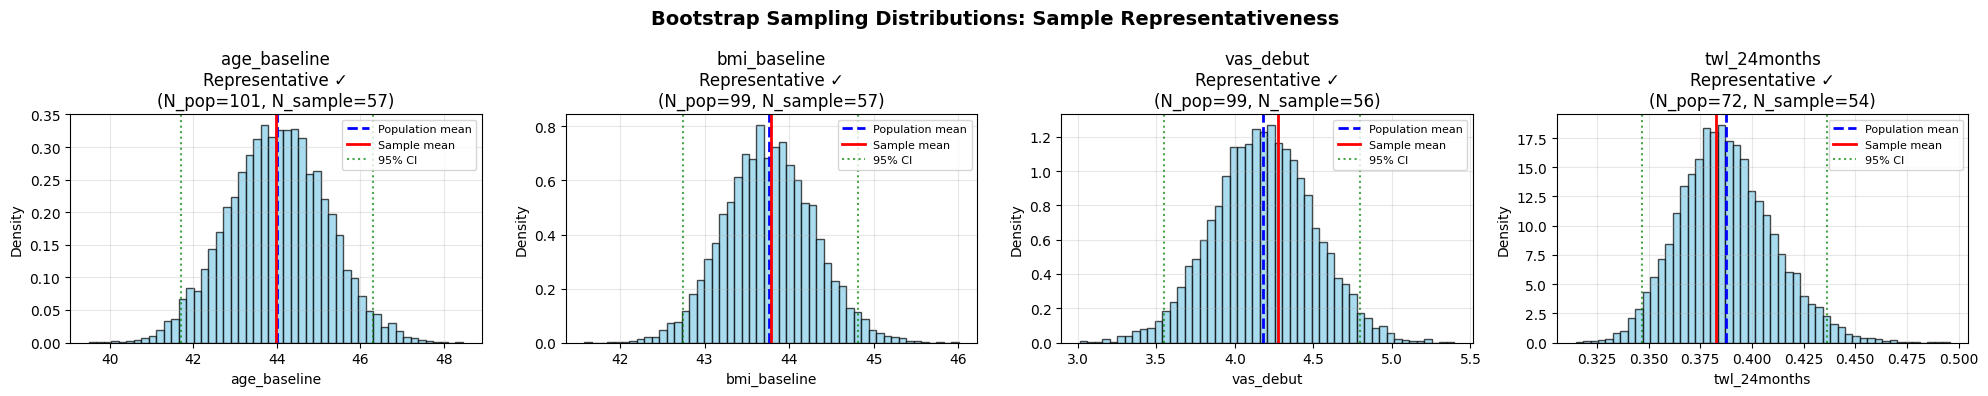



twl_24months added to merged_df for use in AFNI data tables


KeyError: 'twl_24months'

In [28]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# ============================================================
# BOOTSTRAP ANALYSIS: Is analyzed sample representative?
# ============================================================

print("="*80)
print("BOOTSTRAP ANALYSIS: Sample Representativeness")
print("="*80)

# First, check if twl_recherche exists in participants_df
print("\nChecking for TWL data in participants_df...")
print(f"'twl_recherche' column exists: {'twl_recherche' in participants_df.columns}")
if 'twl_recherche' in participants_df.columns:
    print(f"Non-null TWL values: {participants_df['twl_recherche'].notna().sum()}")
    print(f"TWL by session:\n{participants_df.groupby('sess')['twl_recherche'].count()}")

# Extract TWL@24months from session 4
twl_24_mapping = participants_df[participants_df['sess'] == 4][['Subj', 'twl_recherche']].copy()
twl_24_mapping = twl_24_mapping.rename(columns={'twl_recherche': 'twl_24months'})
twl_24_mapping = twl_24_mapping.dropna(subset=['twl_24months'])

print(f"\nSubjects with TWL@24months data: {len(twl_24_mapping)}")
if len(twl_24_mapping) > 0:
    print(f"Sample TWL@24months values:\n{twl_24_mapping.head()}")

# Define key variables to test
key_vars = ['age_baseline', 'bmi_baseline', 'vas_debut', 'twl_24months']

# Get unique subjects at baseline (one row per subject)
participants_baseline = participants_df[participants_df['sess'] == 1].copy()

# Merge TWL@24months into baseline data
participants_baseline = pd.merge(
    participants_baseline,
    twl_24_mapping,
    on='Subj',
    how='left'
)

# Get analyzed sample BEFORE centering (one row per subject at baseline)
base_df = approved_scans[['Subj', 'sess', 'run']].copy()
analyzed_df_uncentered = pd.merge(
    base_df,
    participants_df,
    how='left',
    on=['Subj', 'sess'],
    suffixes=('', '_part')
)

# Get only session 1 (baseline) and keep ONE ROW PER SUBJECT
analyzed_baseline_uncentered = analyzed_df_uncentered[analyzed_df_uncentered['sess'] == 1].copy()
analyzed_baseline_uncentered = analyzed_baseline_uncentered.drop_duplicates(subset=['Subj'])

# Merge TWL@24months into analyzed baseline
analyzed_baseline_uncentered = pd.merge(
    analyzed_baseline_uncentered,
    twl_24_mapping,
    on='Subj',
    how='left'
)

# Convert Subj to set for comparison
all_participants = set(participants_baseline['Subj'].unique())
analyzed_participants = set(analyzed_baseline_uncentered['Subj'].unique())

print(f"\nTotal participants in participants_gb (session 1): {len(all_participants)}")
print(f"Analyzed participants with fMRI data (session 1): {len(analyzed_participants)}")
print(f"Excluded participants: {len(all_participants - analyzed_participants)}")
print(f"Proportion included: {len(analyzed_participants)/len(all_participants):.2%}")

# Check TWL@24months availability
print(f"\nTWL@24months data availability:")
print(f"  Full population with TWL@24months: {participants_baseline['twl_24months'].notna().sum()}")
print(f"  Analyzed sample with TWL@24months: {analyzed_baseline_uncentered['twl_24months'].notna().sum()}")

# Bootstrap parameters
n_bootstrap = 10000
alpha = 0.05

# Store results
bootstrap_results = {}

for var in key_vars:
    print(f"\n{'-'*80}")
    print(f"Variable: {var}")
    print(f"{'-'*80}")
    
    # Get population and sample data
    pop_data = participants_baseline[var].dropna()
    sample_data = analyzed_baseline_uncentered[var].dropna()
    
    if len(pop_data) == 0 or len(sample_data) == 0:
        print(f"  ⚠ Insufficient data for {var}")
        print(f"  Population N: {len(pop_data)}, Sample N: {len(sample_data)}")
        continue
    
    pop_mean = pop_data.mean()
    sample_mean = sample_data.mean()
    
    print(f"Population mean (all participants_gb): {pop_mean:.3f} (N={len(pop_data)})")
    print(f"Sample mean (analyzed participants): {sample_mean:.3f} (N={len(sample_data)})")
    print(f"Difference: {sample_mean - pop_mean:.3f}")
    
    # Bootstrap sampling distribution
    bootstrap_means = []
    
    for i in range(n_bootstrap):
        bootstrap_sample = pop_data.sample(n=len(sample_data), replace=True)
        bootstrap_means.append(bootstrap_sample.mean())
    
    bootstrap_means = np.array(bootstrap_means)
    
    # Calculate confidence interval
    ci_lower = np.percentile(bootstrap_means, alpha/2 * 100)
    ci_upper = np.percentile(bootstrap_means, (1 - alpha/2) * 100)
    
    # Check if sample mean falls within CI
    is_representative = ci_lower <= sample_mean <= ci_upper
    
    # Calculate p-value
    p_value = np.mean(np.abs(bootstrap_means - pop_mean) >= np.abs(sample_mean - pop_mean))
    
    print(f"\nBootstrap Results ({n_bootstrap} iterations):")
    print(f"  95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]")
    print(f"  Sample mean within CI: {'Yes ✓' if is_representative else 'No ✗'}")
    print(f"  P-value: {p_value:.4f}")
    print(f"  Interpretation: {'Sample IS representative' if is_representative else 'Sample may NOT be representative'}")
    
    # Store results
    bootstrap_results[var] = {
        'pop_mean': pop_mean,
        'pop_n': len(pop_data),
        'sample_mean': sample_mean,
        'sample_n': len(sample_data),
        'difference': sample_mean - pop_mean,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'is_representative': is_representative,
        'p_value': p_value,
        'bootstrap_means': bootstrap_means
    }

# Summary table
print(f"\n{'='*80}")
print("SUMMARY TABLE")
print(f"{'='*80}")

summary_df = pd.DataFrame({
    'Variable': [v for v in key_vars if v in bootstrap_results],
    'Pop_N': [bootstrap_results[v]['pop_n'] for v in key_vars if v in bootstrap_results],
    'Sample_N': [bootstrap_results[v]['sample_n'] for v in key_vars if v in bootstrap_results],
    'Population_Mean': [bootstrap_results[v]['pop_mean'] for v in key_vars if v in bootstrap_results],
    'Sample_Mean': [bootstrap_results[v]['sample_mean'] for v in key_vars if v in bootstrap_results],
    'Difference': [bootstrap_results[v]['difference'] for v in key_vars if v in bootstrap_results],
    'CI_Lower': [bootstrap_results[v]['ci_lower'] for v in key_vars if v in bootstrap_results],
    'CI_Upper': [bootstrap_results[v]['ci_upper'] for v in key_vars if v in bootstrap_results],
    'Representative': [bootstrap_results[v]['is_representative'] for v in key_vars if v in bootstrap_results],
    'P_Value': [bootstrap_results[v]['p_value'] for v in key_vars if v in bootstrap_results]
})

print(summary_df.to_string(index=False))

# Overall conclusion
all_representative = all([bootstrap_results[v]['is_representative'] for v in bootstrap_results.keys()])
print(f"\n{'='*80}")
print("OVERALL CONCLUSION")
print(f"{'='*80}")
if all_representative:
    print("✓ Your analyzed sample IS representative of the full participants_gb population")
    print("  on all tested variables (age, BMI, hunger, TWL@24months).")
else:
    non_rep_vars = [v for v in bootstrap_results.keys() if not bootstrap_results[v]['is_representative']]
    print(f"⚠ Your analyzed sample may NOT be fully representative.")
    print(f"  Non-representative variables: {', '.join(non_rep_vars)}")

print(f"\nNote: This analysis uses {n_bootstrap} bootstrap iterations with 95% confidence intervals.")
if 'twl_24months' not in bootstrap_results:
    print(f"Note: TWL@24months excluded from analysis - insufficient data (only available for session 4 completers).")
else:
    print(f"Note: TWL@24months only available for subjects who completed session 4 (24-month follow-up).")

# Create visualization
tested_vars = [v for v in key_vars if v in bootstrap_results]
if len(tested_vars) > 0:
    fig, axes = plt.subplots(1, len(tested_vars), figsize=(5*len(tested_vars), 4))
    if len(tested_vars) == 1:
        axes = [axes]
        
    fig.suptitle('Bootstrap Sampling Distributions: Sample Representativeness', fontsize=14, fontweight='bold')

    for idx, var in enumerate(tested_vars):
        ax = axes[idx]
        
        ax.hist(bootstrap_results[var]['bootstrap_means'], bins=50, alpha=0.7, 
                color='skyblue', edgecolor='black', density=True)
        
        ax.axvline(bootstrap_results[var]['pop_mean'], color='blue', 
                  linestyle='--', linewidth=2, label='Population mean')
        ax.axvline(bootstrap_results[var]['sample_mean'], color='red', 
                  linestyle='-', linewidth=2, label='Sample mean')
        ax.axvline(bootstrap_results[var]['ci_lower'], color='green', 
                  linestyle=':', linewidth=1.5, alpha=0.7)
        ax.axvline(bootstrap_results[var]['ci_upper'], color='green', 
                  linestyle=':', linewidth=1.5, alpha=0.7, label='95% CI')
        
        ax.set_xlabel(var)
        ax.set_ylabel('Density')
        ax.set_title(f"{var}\n{'Representative ✓' if bootstrap_results[var]['is_representative'] else 'Not Representative ✗'}\n(N_pop={bootstrap_results[var]['pop_n']}, N_sample={bootstrap_results[var]['sample_n']})")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

print("\n" + "="*80)

# Add twl_24months to merged_df for AFNI tables
merged_df = pd.merge(
    merged_df,
    twl_24_mapping,
    on='Subj',
    how='left'
)

print("\ntwl_24months added to merged_df for use in AFNI data tables")
print(f"Available for {merged_df['twl_24months'].notna().sum()} out of {len(merged_df)} rows")

## Create the afni databable

In [4]:
# Load QC decision file
import pandas as pd
import os

# Expand the tilde to full path
qc_decision_path_expanded = os.path.expanduser(qc_decision_path)
qc_df = pd.read_csv(qc_decision_path_expanded)

# Display QC dataframe info to understand its structure
print("QC Decision DataFrame columns:", qc_df.columns.tolist())
print("\nFirst few rows of QC data:")
print(qc_df.head())

# Assuming the QC file has columns like: participant_id, session, run, and some decision column
# We need to standardize the column names to match our merged_df format

# Example transformation (adjust based on actual QC file structure):
# If QC has 'participant_id' like 'sub-RCX096', convert to 'rcx096'
if 'participant_id' in qc_df.columns:
    qc_df['Subj'] = qc_df['participant_id'].astype(str).apply(from_afni_id)
elif 'subject' in qc_df.columns:
    qc_df['Subj'] = qc_df['subject'].astype(str).apply(from_afni_id)

# Standardize session column
if 'session' in qc_df.columns:
    qc_df['sess'] = pd.to_numeric(qc_df['session'], errors='coerce')
elif 'ses' in qc_df.columns:
    qc_df['sess'] = pd.to_numeric(qc_df['ses'], errors='coerce')

# Standardize run column
if 'run' in qc_df.columns:
    qc_df['run'] = pd.to_numeric(qc_df['run'], errors='coerce')

# Filter to only "good" quality scans
# Adjust the column name and value based on your QC file
# Common patterns: 'decision', 'qc_decision', 'include', 'exclude', etc.
if 'decision' in qc_df.columns:
    qc_good = qc_df[qc_df['decision'] == 'include'].copy()
elif 'qc_decision' in qc_df.columns:
    qc_good = qc_df[qc_df['qc_decision'] == 'pass'].copy()
elif 'include' in qc_df.columns:
    qc_good = qc_df[qc_df['include'] == True].copy()
else:
    print("Available columns:", qc_df.columns.tolist())
    print("\nPlease specify the decision column name and acceptable values")
    qc_good = qc_df.copy()  # Fallback: use all

# Create a merge key to filter merged_df
qc_good['merge_key'] = qc_good['Subj'] + '_' + qc_good['sess'].astype(str) + '_' + qc_good['run'].astype(str)
merged_df['merge_key'] = merged_df['Subj'] + '_' + merged_df['sess'].astype(str) + '_' + merged_df['run'].astype(str)

# Filter merged_df to only include QC-approved scans
merged_df_qc_filtered = merged_df[merged_df['merge_key'].isin(qc_good['merge_key'])].copy()

# Remove the temporary merge_key column
merged_df_qc_filtered = merged_df_qc_filtered.drop(columns=['merge_key'])
if 'merge_key' in merged_df.columns:
    merged_df = merged_df.drop(columns=['merge_key'])

print(f"\nRows before QC filtering: {len(merged_df)}")
print(f"Rows after QC filtering: {len(merged_df_qc_filtered)}")
print(f"Rows removed: {len(merged_df) - len(merged_df_qc_filtered)}")

# Now use merged_df_qc_filtered for creating output tables
merged_df_qc_filtered.head()

QC Decision DataFrame columns: ['bids_name', 'aqi', 'aor', 'aor_zscore', 'Unnamed: 4', 'aqi_zscore', 'dummy_trs', 'dummy_trs_zscore', 'dvars_nstd', 'dvars_nstd_zscore', 'dvars_std', 'dvars_std_zscore', 'dvars_vstd', 'dvars_vstd_zscore', 'efc', 'efc_zscore', 'fber', 'fber_zscore', 'fd_mean', 'fd_mean_zscore', 'fd_num', 'fd_num_zscore', 'fd_perc', 'fd_perc_zscore', 'fwhm_avg', 'fwhm_avg_zscore', 'fwhm_x', 'fwhm_x_zscore', 'fwhm_y', 'fwhm_y_zscore', 'fwhm_z', 'fwhm_z_zscore', 'gcor', 'gcor_zscore', 'gsr_x', 'gsr_x_zscore', 'gsr_y', 'gsr_y_zscore', 'size_t', 'size_t_zscore', 'size_x', 'size_x_zscore', 'size_y', 'size_y_zscore', 'size_z', 'size_z_zscore', 'snr', 'snr_zscore', 'spacing_tr', 'spacing_tr_zscore', 'spacing_x', 'spacing_x_zscore', 'spacing_y', 'spacing_y_zscore', 'spacing_z', 'spacing_z_zscore', 'summary_bg_k', 'summary_bg_k_zscore', 'summary_bg_mad', 'summary_bg_mad_zscore', 'summary_bg_mean', 'summary_bg_mean_zscore', 'summary_bg_median', 'summary_bg_median_zscore', 'summary_b

KeyError: 'Subj'

## read participant df

In [27]:
import pandas as pd

# Read the participants file (TSV)
participants_df = pd.read_csv(participants_input_path, sep='\t')

lme_df = pd.read_csv(
    data_table_format_input_path,
    sep=r'\s+',
    header=0,
    index_col=None,
    engine='python'
)


## describe participant df and input file df

In [ ]:
# Show summary info for participants_df
participants_df.info(verbose=True, show_counts=True)

# Per-column summary table for participants_df
participants_col_info = pd.DataFrame({
    'dtype': participants_df.dtypes.astype(str),
    'non_null': participants_df.count(),
    'n_unique(incl_NaN)': participants_df.nunique(bids_name	aqi	aor	aor_zscore	Unnamed: 4	aqi_zscore	dummy_trs	dummy_trs_zscore	dvars_nstd	dvars_nstd_zscore	dvars_std	dvars_std_zscore	dvars_vstd	dvars_vstd_zscore	efc	efc_zscore	fber	fber_zscore	fd_mean	fd_mean_zscore	fd_num	fd_num_zscore	fd_perc	fd_perc_zscore	fwhm_avg	fwhm_avg_zscore	fwhm_x	fwhm_x_zscore	fwhm_y	fwhm_y_zscore	fwhm_z	fwhm_z_zscore	gcor	gcor_zscore	gsr_x	gsr_x_zscore	gsr_y	gsr_y_zscore	size_t	size_t_zscore	size_x	size_x_zscore	size_y	size_y_zscore	size_z	size_z_zscore	snr	snr_zscore	spacing_tr	spacing_tr_zscore	spacing_x	spacing_x_zscore	spacing_y	spacing_y_zscore	spacing_z	spacing_z_zscore	summary_bg_k	summary_bg_k_zscore	summary_bg_mad	summary_bg_mad_zscore	summary_bg_mean	summary_bg_mean_zscore	summary_bg_median	summary_bg_median_zscore	summary_bg_n	summary_bg_n_zscore	summary_bg_p05	summary_bg_p05_zscore	summary_bg_p95	summary_bg_p95_zscore	summary_bg_stdv	summary_bg_stdv_zscore	summary_fg_k	summary_fg_k_zscore	summary_fg_mad	summary_fg_mad_zscore	summary_fg_mean	summary_fg_mean_zscore	summary_fg_median	summary_fg_median_zscore	summary_fg_n	summary_fg_n_zscore	summary_fg_p05	summary_fg_p05_zscore	summary_fg_p95	summary_fg_p95_zscore	summary_fg_stdv	summary_fg_stdv_zscore	tsnr	tsnr_zscore	Coverage_percentage	Coverage_percentage_zscore	fd_max	fd_max_zscore	fd_num_above_3mm	fd_num_above_3mm_zscore	Session	Distorsion cou	decision	Commentaire (raison d’exclusion	Changement 2e passe	status_cath	mismatch	Reconciliation cath pat	Decision finale	Commentaire final
sub-RCX097_ses-1_task-BDM_run-1_bold	0.018503304	0.002640307	-0.608484289		-0.1685398	1	0.760626741	30.5232422	-0.755448424	1.134605664	-0.725645111	0.957528244	-0.748709791	0.3909	-0.265283108	153021.3281	-0.152082613	0.263172416	-0.67156771	98	-0.566657536	60.12269939	-0.502056824	2.628172222	1.685940984	2.564846667	1.252127432	2.710003333	1.772506926	2.609666667	1.680189341	0.0151646	-1.023550845	-0.017389271	-0.718952005	0.018241055	1.110154056	163	-0.501184314	80		80		45		2.898630068	-0.509375059	2.749999285	2.055824675	3		3		3		233.6844	2.793745355	60.8876	-1.422417436	512.4942	-1.502161589	51	-1.463351607	238040	0.231345324	1	-1.007935564	2144	-1.488727809	1657.5555	-1.374517364	0.7538	-2.220179249	4510.9591	-1.72892588	18546.5894	-1.906458045	19781	-1.865638097	49960	-0.231345324	3241	-1.917725033	27063	-1.880740046	6824.1899	-1.777727682	44.32727944	0.033189182	99.4	0.103372941	1.033935306	-0.59473749	0	-0.280563898	1	non	inclure			include	False		inclure	
sub-RCX097_ses-1_task-BDM_run-2_bold	0.032157826	0.009152235	-0.211273222		0.296972384	0	-0.292841295	33.29994747	-0.577122173	1.150676004	-0.630480002	1.016527375	-0.372298517	0.3937	-0.13588648	155226.1562	-0.125544928	0.333245187	-0.4291738	97	-0.591921359	57.05882353	-0.635627164	2.669513333	2.000542819	2.571606667	1.295745437	2.75502	2.092264046	2.681913333	2.229358646	0.0171683	-0.917172359	-0.017361104	-0.712923351	0.018683389	1.175476117	170	0.195943652	80		80		45		2.944925081	-0.285286814	2.749999285	2.055824675	3		3		3		243.8903	3.027985625	59.7509	-1.438510739	519.4175	-1.488219371	50	-1.482014056	237645	0.143710697	1	-1.007935564	2196	-1.467894476	1659.2486	-1.373294559	0.8469	-1.951856893	4263.2285	-1.804537309	18487.7356	-1.910310622	19779	-1.865768348	50355	-0.143710697	3289	-1.908346199	26697	-1.896094992	6716.2332	-1.798282028	32.68821281	-0.801588291	96.42	-0.180172709	1.969070983	-0.132412307	0	-0.280563898	1	non	inclure	artefact distorsion PFC, carpet plot quelques coupures drastiques mais ok	non	include	False		inclure	
sub-RCX097_ses-2_task-BDM_run-1_bold	0.006067645	0.001446235	-0.706503004		-0.548517043	0	-0.274290193	31.37824202	-0.300245098	1.418984915	0.926322712	0.993336945	-0.560615569	0.3785	-0.599344871	266477	0.269635789	0.125306417	-0.817438988	26	-1.396386144	15.29411765	-1.411291741	2.507145556	0.771109913	2.456176667	0.59633478	2.653916667	1.303363151	2.411343333	0.214197121	0.00997331	-1.30826491	-0.011384131	0.639773366	0.005294871	-0.80895046	170	0.260555985	80		80		45		2.91311534	-0.446598595	2.749998331	-0.268961755	3		3		3		107.6329	-0.324170054	165.5143	0.151822229	1310.493	-0.089418659	134	0.13906552	238098	0.17273833	3	-0.238972061	5357	-0.460331209	4201.853	0.099242002	1.0202	-1.455908341	14788.0971	0.988010214	64788.6	0.722978712	68960.5	0.970178096	49902	-0.17273833	11226	-0.820110534	94081	0.48718094	23672.1863	1.011595853	70.09405329	1.46989089	97.02	-0.041372902	0.359677486	-0.856693134	0	-0.292272069	2	oui	inclure			include	False		inclure	
sub-RCX097_ses-2_task-BDM_run-2_bold	0.004897541	0.002686235	-0.648188028		-0.585276712	0	-0.274290193	32.68566201	-0.208539089	1.492981796	1.330476333	1.030890257	-0.343431664	0.3794	-0.555810597	263486.5	0.248167047	0.12826385	-0.806597514	18	-1.571259698	11.11111111	-1.566594366	2.495531111	0.689491753	2.446616667	0.53796789	2.64304	1.23280024	2.396936667	0.113401655	0.0198711	-0.721866619	-0.011683638	0.569534526	0.005116828	-0.836717862	162	-0.984185404	80		80		45		2.931492392	-0.342701242	2.749998331	-0.268961755	3		3		3		106.1048	-0.355832782	168.0441	0.206848291	1345.9174	0.001892108	136	0.19256859	238088	0.17041088	4	0.036009489	5515	-0.381636167	4297.73	0.17958817	1.0563	-1.344768509	14780.7768	0.98548278	65458.4792	0.777071583	69692.5	1.02863195	49912	-0.17041088	11357	-0.789061548	94639	0.515226835	23773.4889	1.033992033	77.84214699	1.958555669	98.8	0.114709765	0.564829154	-0.756225947	0	-0.292272069	2	non	inclure			include	False		inclure	
sub-RCX097_ses-2_task-BDM_run-3_bold	0.006361762	0.003798221	-0.595893276		-0.539277147	0	-0.274290193	33.68513587	-0.138433263	1.503930328	1.390274649	1.037361285	-0.30600745	0.3798	-0.536462031	262981.0312	0.244538296	0.132773798	-0.790064767	28	-1.352667756	17.17791411	-1.341351967	2.502422222	0.737917643	2.451646667	0.568677666	2.651303333	1.286409022	2.404316667	0.165035427	0.02378	-0.490282368	-0.011770455	0.549174647	0.00560298	-0.760897903	163	-0.82859273	80		80		45		2.930222046	-0.349883329	2.749998331	-0.268961755	3		3		3		101.9665	-0.441579702	167.6744	0.19880689	1339.5237	-0.014588444	135	0.165817055	238008	0.151791283	3	-0.238972061	5514	-0.382134237	4253.1888	0.142262067	1.0322	-1.418964352	14716.77	0.963383549	64908.274	0.73264241	69161	0.986189022	49992	-0.151791283	11290	-0.804941564	93947	0.480445905	23602.4121	0.996170034	68.33698802	1.359074482	98.8	0.114709765	0.551941764	-0.762537179	0	-0.292272069	2	non	inclure			include	False		inclure	
dropna=False),
    'pct_missing': (participants_df.isna().mean() * 100).round(2),
    'sample_values_first5': participants_df.apply(lambda s: s.dropna().unique()[:5].tolist())
})

# Descriptive statistics for participants_df
participants_desc_all = participants_df.describe(include='all').T

# Show summary info for lme_df
lme_df.info(verbose=True, show_counts=True)

# Per-column summary table for lme_df
lme_col_info = (
    lme_df.dtypes.astype(str).to_frame('dtype')
    .join(lme_df.count().to_frame('non_null'))
    .join(lme_df.nunique(dropna=False).to_frame('n_unique(incl_NaN)'))
    .join((lme_df.isna().mean() * 100).round(2).to_frame('pct_missing'))
    .join(lme_df.apply(lambda s: s.dropna().unique()[:5].tolist()).to_frame('sample_values_first5'))
)

# Descriptive statistics for lme_df
lme_desc_all = lme_df.describe(include='all').T

participants_col_info, participants_desc_all, lme_col_info, lme_desc_all

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 444 entries, 0 to 443
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   participant_id  444 non-null    object 
 1   session         444 non-null    object 
 2   sex             404 non-null    object 
 3   age             335 non-null    float64
 4   weight          360 non-null    float64
 5   imc_recherche   355 non-null    float64
 6   ewl_recherche   355 non-null    float64
 7   twl_recherche   360 non-null    float64
 8   bi_ttaille      336 non-null    float64
 9   bi_thanche      336 non-null    float64
 10  bi_tcou         336 non-null    float64
 11  t2d             400 non-null    float64
 12  tx_t2d___1      444 non-null    float64
 13  tx_t2d___2      444 non-null    float64
 14  tx_t2d___3      444 non-null    float64
 15  type_chx        388 non-null    float64
 16  handedness      376 non-null    object 
 17  qte_boost       332 non-null    flo

(                  dtype  non_null  n_unique(incl_NaN)  pct_missing  \
 participant_id   object       444                 111         0.00   
 session          object       444                   5         0.00   
 sex              object       404                   3         9.01   
 age             float64       335                 217        24.55   
 weight          float64       360                 291        18.92   
 imc_recherche   float64       355                 352        20.05   
 ewl_recherche   float64       355                 257        20.05   
 twl_recherche   float64       360                 257        18.92   
 bi_ttaille      float64       336                  96        24.32   
 bi_thanche      float64       336                  91        24.32   
 bi_tcou         float64       336                  44        24.32   
 t2d             float64       400                   3         9.91   
 tx_t2d___1      float64       444                   2         0.00   
 tx_t2

In [29]:
import re

# Function to convert 'sub-RCX096' → 'rcx096', 'sub-RND001' → 'rnd001'
def from_afni_id(x):
    m = re.match(r"sub-([A-Z]+)(\d+)", x)
    if m:
        prefix = m.group(1).lower()
        number = m.group(2).zfill(3)
        return f"{prefix}{number}"
    return x

# Apply conversion and rename columns
participants_df = participants_df.rename(columns={'participant_id': 'Subj', 'session': 'sess'})
participants_df['Subj'] = participants_df['Subj'].astype(str).apply(from_afni_id)
participants_df['sess'] = pd.to_numeric(participants_df['sess'], errors='coerce')

In [30]:
# First, check what columns actually exist in lme_df
print("Columns in lme_df:", lme_df.columns.tolist())
print("\nFirst few rows of lme_df:")
print(lme_df.head())

# Check if the column exists before trying to rename
if 'session' in lme_df.columns:
    lme_df = lme_df.rename(columns={'session': 'sess'})
elif 'sess' in lme_df.columns:
    print("Column 'sess' already exists, no need to rename")
else:
    # Find similar column names that might be the session column
    possible_sess_cols = [col for col in lme_df.columns if 'sess' in col.lower() or 'time' in col.lower()]
    print(f"Possible session columns: {possible_sess_cols}")

# Same check for participant_id
if 'participant_id' in lme_df.columns:
    lme_df = lme_df.rename(columns={'participant_id': 'Subj'})
elif 'Subj' not in lme_df.columns:
    possible_subj_cols = [col for col in lme_df.columns if 'subj' in col.lower() or 'participant' in col.lower()]
    print(f"Possible subject columns: {possible_subj_cols}")

# Now check participants_df columns
print("\nColumns in participants_df:", participants_df.columns.tolist())

Columns in lme_df: ['Subj', 'Session', 'Run', 'age', 'main_dominante', 'imc_baseline', 'type_chx', 'sexe', 'EffectMap', 'VarMap']

First few rows of lme_df:
     Subj  Session  Run   age  main_dominante  imc_baseline  type_chx  sexe  \
0  RCX146        2    3  43.8             1.0     41.097264       2.0   2.0   
1  RCX146        2    2  43.8             1.0     41.097264       2.0   2.0   
2  RCX146        1    1  43.8             1.0     41.097264       2.0   2.0   
3  RCX146        1    2  43.8             1.0     41.097264       2.0   2.0   
4  RCX146        4    1  43.8             1.0     41.097264       2.0   2.0   

                                           EffectMap  \
0  /home/pagag24/projects/def-amichaud/share/GutB...   
1  /home/pagag24/projects/def-amichaud/share/GutB...   
2  /home/pagag24/projects/def-amichaud/share/GutB...   
3  /home/pagag24/projects/def-amichaud/share/GutB...   
4  /home/pagag24/projects/def-amichaud/share/GutB...   

                               

In [31]:
# Rename columns in lme_df to match our naming convention
# Session (capital S) → sess, Run → run, EffectMap → InputFile
lme_df = lme_df.rename(columns={
    'Session': 'sess',
    'Run': 'run',
    'EffectMap': 'InputFile'
})

# Make sure types match for merging
lme_df['Subj'] = lme_df['Subj'].astype(str).str.strip()
lme_df['sess'] = pd.to_numeric(lme_df['sess'], errors='coerce')
participants_df['Subj'] = participants_df['Subj'].astype(str).str.strip()
participants_df['sess'] = pd.to_numeric(participants_df['sess'], errors='coerce')

# Merge: left join to keep all rows from lme_df
merged_df = pd.merge(
    lme_df,
    participants_df,
    how='left',
    on=['Subj', 'sess'],
    suffixes=('_lme', '_part')
)

print(f"Rows in lme_df: {len(lme_df)}, Rows in merged_df: {len(merged_df)}")
merged_df.head(50)

Rows in lme_df: 419, Rows in merged_df: 419


,Subj,sess,run,age_lme,main_dominante,imc_baseline,type_chx_lme,sexe,InputFile,VarMap,...,tx_t2d___1,tx_t2d___2,tx_t2d___3,type_chx_part,handedness,qte_boost,vas_debut,vas_fin,age_baseline,bmi_baseline
0,RCX146,2,3,43.8,1.0,41.097264,2.0,2.0,/home/pagag24/projects/def-amichaud/share/GutB...,/home/pagag24/projects/def-amichaud/share/GutB...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,RCX146,2,2,43.8,1.0,41.097264,2.0,2.0,/home/pagag24/projects/def-amichaud/share/GutB...,/home/pagag24/projects/def-amichaud/share/GutB...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,RCX146,1,1,43.8,1.0,41.097264,2.0,2.0,/home/pagag24/projects/def-amichaud/share/GutB...,/home/pagag24/projects/def-amichaud/share/GutB...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,RCX146,1,2,43.8,1.0,41.097264,2.0,2.0,/home/pagag24/projects/def-amichaud/share/GutB...,/home/pagag24/projects/def-amichaud/share/GutB...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,RCX146,4,1,43.8,1.0,41.097264,2.0,2.0,/home/pagag24/projects/def-amichaud/share/GutB...,/home/pagag24/projects/def-amichaud/share/GutB...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,RCX200,4,1,48.7,1.0,43.516840,1.0,2.0,/home/pagag24/projects/def-amichaud/share/GutB...,/home/pagag24/projects/def-amichaud/share/GutB...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,RCX200,4,2,48.7,1.0,43.516840,1.0,2.0,/home/pagag24/projects/def-amichaud/share/GutB...,/home/pagag24/projects/def-amichaud/share/GutB...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,RCX200,3,1,48.7,1.0,43.516840,1.0,2.0,/home/pagag24/projects/def-amichaud/share/GutB...,/home/pagag24/projects/def-amichaud/share/GutB...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,RCX200,2,2,48.7,1.0,43.516840,1.0,2.0,/home/pagag24/projects/def-amichaud/share/GutB...,/home/pagag24/projects/def-amichaud/share/GutB...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,RCX200,2,3,48.7,1.0,43.516840,1.0,2.0,/home/pagag24/projects/def-amichaud/share/GutB...,/home/pagag24/projects/def-amichaud/share/GutB...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
print("lme_df['Subj'] unique:", lme_df['Subj'].unique()[:10])
print("participants_df['Subj'] unique:", participants_df['Subj'].unique()[:10])
print("lme_df['sess'] unique:", lme_df['sess'].unique())
print("participants_df['sess'] unique:", participants_df['sess'].unique())

lme_df['Subj'] unique: ['RCX146' 'RCX200' 'RND009' 'RCX097' 'RND074' 'RND003' 'RND022' 'RCX219'
 'RND067' 'RND010']
participants_df['Subj'] unique: ['rcx096' 'rnd001' 'rnd002' 'rnd004' 'rnd003' 'rcx097' 'rnd005' 'rnd006'
 'rnd007' 'rnd008']
lme_df['sess'] unique: [2 1 4 3]
participants_df['sess'] unique: [ 1.  2.  3.  4. nan]


In [33]:
lme_df['Subj'] = lme_df['Subj'].str.strip()
participants_df['Subj'] = participants_df['Subj'].str.strip()

In [34]:
print("lme_df['Subj'] unique:", sorted(lme_df['Subj'].unique()))
print("participants_df['Subj'] unique:", sorted(participants_df['Subj'].unique()))

lme_df['Subj'] unique: ['RCX097', 'RCX126', 'RCX136', 'RCX146', 'RCX148', 'RCX164', 'RCX191', 'RCX200', 'RCX211', 'RCX219', 'RCX247', 'RND003', 'RND004', 'RND005', 'RND007', 'RND009', 'RND010', 'RND011', 'RND013', 'RND014', 'RND015', 'RND016', 'RND018', 'RND020', 'RND021', 'RND022', 'RND023', 'RND024', 'RND025', 'RND027', 'RND029', 'RND030', 'RND032', 'RND033', 'RND034', 'RND035', 'RND037', 'RND038', 'RND041', 'RND044', 'RND047', 'RND048', 'RND049', 'RND050', 'RND051', 'RND052', 'RND059', 'RND061', 'RND062', 'RND067', 'RND068', 'RND069', 'RND070', 'RND071', 'RND072', 'RND073', 'RND074', 'RND076']
participants_df['Subj'] unique: ['rcx096', 'rcx097', 'rcx126', 'rcx136', 'rcx146', 'rcx147', 'rcx148', 'rcx164', 'rcx191', 'rcx200', 'rcx203', 'rcx211', 'rcx219', 'rcx247', 'rgc901', 'rgc902', 'rgc903', 'rgc904', 'rgc905', 'rgc906', 'rgc907', 'rgc908', 'rgc910', 'rgc911', 'rgc912', 'rgc913', 'rgc914', 'rgc915', 'rgc916', 'rgc917', 'rgc918', 'rgc919', 'rgc920', 'rgc921', 'rgc922', 'rgc923', 'rg

In [35]:
lme_df['Subj'] = lme_df['Subj'].astype(str).str.strip()
participants_df['Subj'] = participants_df['Subj'].astype(str).str.strip()

In [36]:
lme_df['sess'] = pd.to_numeric(lme_df['sess'], errors='coerce')
participants_df['sess'] = pd.to_numeric(participants_df['sess'], errors='coerce')

In [37]:
print("NaN in lme_df['sess']:", lme_df['sess'].isna().sum())
print("NaN in participants_df['sess']:", participants_df['sess'].isna().sum())

NaN in lme_df['sess']: 0
NaN in participants_df['sess']: 24


In [38]:
print(lme_df.columns)

Index(['Subj', 'sess', 'run', 'age', 'main_dominante', 'imc_baseline',
       'type_chx', 'sexe', 'InputFile', 'VarMap'],
      dtype='object')


In [22]:
merged_df = pd.merge(
    lme_df,
    participants_df,
    how='left',
    on=['Subj', 'sess'],
    suffixes=('', '_part')
)
print(f"Rows in lme_df: {len(lme_df)}, Rows in merged_df: {len(merged_df)}")
merged_df.head(75)

baseline_df = merged_df[merged_df['sess'] == 1]
mean_age = baseline_df['age_baseline'].mean()
std_age = baseline_df['age_baseline'].std()
mean_bmi = baseline_df['bmi_baseline'].mean()
std_bmi = baseline_df['bmi_baseline'].std()
print(f"Mean age at baseline: {mean_age:.2f} (SD: {std_age:.2f})")
print(f"Mean BMI at baseline: {mean_bmi:.2f} (SD: {std_bmi:.2f})")

# Sample size (number of unique participants) for each session
sample_size_per_session = merged_df.groupby('sess')['Subj'].nunique()
print("\nSample size (unique participants) per session:")
print(sample_size_per_session)

Rows in lme_df: 419, Rows in merged_df: 419
Mean age at baseline: nan (SD: nan)
Mean BMI at baseline: nan (SD: nan)

Sample size (unique participants) per session:
sess
1    58
2    46
3    42
4    42
Name: Subj, dtype: int64


In [15]:
def extract_run(inputfile):
    m = re.search(r'run(\d+)', str(inputfile))
    if m:
        return int(m.group(1))
    return None

merged_df['run'] = merged_df['InputFile'].apply(extract_run)

cols_to_drop = [col.strip() for col in [
    'weight', 'imc_recherche', 'ewl_recherche', 'twl_recherche',
    'bi_ttaille', 'bi_thanche', 'bi_tcou',
    'tx_t2d___3', 'qte_boost', 'tx_t2d___2', 'age', 'vas_fin', 't2d', ' tx_t2d___1'
]]

merged_df = merged_df.drop(columns=[col for col in cols_to_drop if col in merged_df.columns])

# Grand mean center selected columns (overwrite with same name)
for col in ['vas_debut', 'age_baseline', 'bmi_baseline']:
    if col in merged_df.columns:
        merged_df[col] = merged_df[col] - merged_df[col].mean()


# Convert sess, type_chx, and run to string for categorical treatment in AFNI
for col in ['sess', 'type_chx', 'run']:
    if col in merged_df.columns:
        merged_df[col] = merged_df[col].astype(int).astype(str)





In [16]:
# Show summary info for merged_df
merged_df.info(verbose=True, show_counts=True)

# Per-column summary table for merged_df
merged_col_info = pd.DataFrame({
    'dtype': merged_df.dtypes.astype(str),
    'non_null': merged_df.count(),
    'n_unique(incl_NaN)': merged_df.nunique(dropna=False),
    'pct_missing': (merged_df.isna().mean() * 100).round(2),
    'sample_values_first5': merged_df.apply(lambda s: s.dropna().unique()[:5].tolist())
})

# Descriptive statistics for merged_df
merged_desc_all = merged_df.describe(include='all').T

merged_col_info, merged_desc_all




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404 entries, 0 to 403
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Subj          404 non-null    object 
 1   sess          404 non-null    object 
 2   InputFile     404 non-null    object 
 3   sex           404 non-null    object 
 4   type_chx      404 non-null    object 
 5   handedness    404 non-null    object 
 6   vas_debut     399 non-null    float64
 7   age_baseline  404 non-null    float64
 8   bmi_baseline  404 non-null    float64
 9   run           404 non-null    object 
dtypes: float64(3), object(7)
memory usage: 31.7+ KB


(                dtype  non_null  n_unique(incl_NaN)  pct_missing  \
 Subj           object       404                  56         0.00   
 sess           object       404                   4         0.00   
 InputFile      object       404                 404         0.00   
 sex            object       404                   2         0.00   
 type_chx       object       404                   3         0.00   
 handedness     object       404                   2         0.00   
 vas_debut     float64       399                  53         1.24   
 age_baseline  float64       404                  53         0.00   
 bmi_baseline  float64       404                  56         0.00   
 run            object       404                   3         0.00   
 
                                            sample_values_first5  
 Subj                   [rcx097, rcx126, rcx136, rcx146, rcx148]  
 sess                                               [1, 2, 3, 4]  
 InputFile     [rcx097_ses1_run2_Hi_vs

In [17]:
# Impute missing values by mean within each session
numeric_cols = merged_df.select_dtypes(include='number').columns

for col in numeric_cols:
    merged_df[col] = merged_df.groupby('sess')[col].transform(lambda x: x.fillna(x.mean()))

    # Move 'InputFile' to the last column
    cols = [c for c in merged_df.columns if c != 'InputFile'] + ['InputFile']
    merged_df = merged_df[cols]

# If you want to check the result:
merged_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404 entries, 0 to 403
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Subj          404 non-null    object 
 1   sess          404 non-null    object 
 2   sex           404 non-null    object 
 3   type_chx      404 non-null    object 
 4   handedness    404 non-null    object 
 5   vas_debut     404 non-null    float64
 6   age_baseline  404 non-null    float64
 7   bmi_baseline  404 non-null    float64
 8   run           404 non-null    object 
 9   InputFile     404 non-null    object 
dtypes: float64(3), object(7)
memory usage: 31.7+ KB


In [18]:
merged_df.head(50)

,Subj,sess,sex,type_chx,handedness,vas_debut,age_baseline,bmi_baseline,run,InputFile
0,rcx097,1,female,3,right,-0.060560,-3.750495,-0.133239,2,rcx097_ses1_run2_Hi_vs_Lo.nii
1,rcx097,2,female,3,right,-3.125815,-3.750495,-0.133239,1,rcx097_ses2_run1_Hi_vs_Lo.nii
2,rcx097,2,female,3,right,-3.125815,-3.750495,-0.133239,2,rcx097_ses2_run2_Hi_vs_Lo.nii
3,rcx097,2,female,3,right,-3.125815,-3.750495,-0.133239,3,rcx097_ses2_run3_Hi_vs_Lo.nii
4,rcx097,3,female,3,right,-4.125815,-3.750495,-0.133239,1,rcx097_ses3_run1_Hi_vs_Lo.nii
5,rcx097,3,female,3,right,-4.125815,-3.750495,-0.133239,2,rcx097_ses3_run2_Hi_vs_Lo.nii
6,rcx097,4,female,3,right,-3.125815,-3.750495,-0.133239,1,rcx097_ses4_run1_Hi_vs_Lo.nii
7,rcx126,1,female,1,right,-0.725815,14.249505,3.603739,1,rcx126_ses1_run1_Hi_vs_Lo.nii
8,rcx126,1,female,1,right,-0.725815,14.249505,3.603739,2,rcx126_ses1_run2_Hi_vs_Lo.nii
9,rcx126,2,female,1,right,-1.725815,14.249505,3.603739,1,rcx126_ses2_run1_Hi_vs_Lo.nii


In [19]:
merged_df.to_csv(output_path, sep='\t', index=False)

In [20]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from patsy import dmatrix

# Columns to exclude from VIF analysis
exclude_cols = [
    'age', 'twl_recherche', 'imc_recherche', 'ewl_recherche',
    'weight', 'bi_thanche', 'bi_ttaille', 'bi_tcou'
]

# Select all columns except 'Subj', 'InputFile', and excluded columns
cols_for_vif = [
    col for col in merged_df.columns
    if col not in ['Subj', 'InputFile'] and col not in exclude_cols
]

# Create a design matrix with one-hot encoding for categoricals (drop first to avoid dummy trap)
X = dmatrix(
    " + ".join([
        f"C({col})" if str(merged_df[col].dtype) in ["object", "category"] else col
        for col in cols_for_vif
    ]),
    merged_df,
    return_type='dataframe'
).dropna()

# Remove problematic columns if they exist
for col in ["C(t2d)[T.2.0]", "C(t2d)[T.2]"]:
    if col in X.columns:
        X = X.drop(columns=[col])

# Compute VIF for each column in the design matrix
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data.sort_values("VIF", ascending=False))

                   feature        VIF
0                Intercept  27.160200
6         C(type_chx)[T.3]   1.930525
11            age_baseline   1.670114
5         C(type_chx)[T.2]   1.533477
2             C(sess)[T.3]   1.422199
1             C(sess)[T.2]   1.413209
3             C(sess)[T.4]   1.384172
7   C(handedness)[T.right]   1.355385
12            bmi_baseline   1.337329
9              C(run)[T.3]   1.231148
8              C(run)[T.2]   1.226827
4           C(sex)[T.male]   1.174740
10               vas_debut   1.158808


# data table for mod_view v.s. view_cros

In [21]:
# --- Place this after merged_df is created, before any modifications to merged_df ---

def make_new_inputfile(row):
    subj = str(row['Subj']).upper()
    sess = str(row['sess'])
    run = str(row['run'])
    return f"/home/pagag24/projects/def-amichaud/share/GutBrain/BIDS_results2/sub-{subj}/ses-{sess}/func/sub-{subj}_ses-{sess}_run-{run}_effect-size_ssib_v2_simple_mod_view_vs_cross.nii.gz"

# If 'run' column is not present, extract it from InputFile
if 'run' not in merged_df.columns:
    import re
    def extract_run(inputfile):
        m = re.search(r'run-?(\d+)', str(inputfile))
        if m:
            return m.group(1)
        return None
    merged_df['run'] = merged_df['InputFile'].apply(extract_run)

# Create a new table with the same rows but new InputFile paths
mod_view_vs_cross_table = merged_df.copy()
mod_view_vs_cross_table['InputFile'] = mod_view_vs_cross_table.apply(make_new_inputfile, axis=1)

# Save to a new file
output_path_mod_view_vs_cross = output_path.replace('.txt', '_mod_view_vs_cross.txt')
mod_view_vs_cross_table.to_csv(output_path_mod_view_vs_cross, sep='\t', index=False)

print(f"New table with updated InputFile column saved to: {output_path_mod_view_vs_cross}")

New table with updated InputFile column saved to: \\wsl.localhost\Ubuntu\home\gagpat01\mes_projets\maitrise\fmri\results\3dlmerdata_table_with_covariates_mod_view_vs_cross.txt


# data table for view vs view_cross

In [22]:
# --- Create data table for view_vs_view_cross ---

def make_view_vs_view_cross_inputfile(row):
    subj = str(row['Subj']).upper()
    sess = str(row['sess'])
    run = str(row['run'])
    return f"/home/pagag24/projects/def-amichaud/share/GutBrain/BIDS_results2/sub-{subj}/ses-{sess}/func/sub-{subj}_ses-{sess}_run-{run}_effect-size_v4_simple_view_vs_view_cross.nii.gz"

# If 'run' column is not present, extract it from InputFile
if 'run' not in merged_df.columns:
    import re
    def extract_run(inputfile):
        m = re.search(r'run-?(\d+)', str(inputfile))
        if m:
            return m.group(1)
        return None
    merged_df['run'] = merged_df['InputFile'].apply(extract_run)

# Create a new table with the same rows but new InputFile paths
view_vs_view_cross_table = merged_df.copy()
view_vs_view_cross_table['InputFile'] = view_vs_view_cross_table.apply(make_view_vs_view_cross_inputfile, axis=1)

# Save to a new file
output_path_view_vs_view_cross = output_path.replace('.txt', '_view_vs_view_cross.txt')
view_vs_view_cross_table.to_csv(output_path_view_vs_view_cross, sep='\t', index=False, lineterminator='\n')

print(f"New table with view_vs_view_cross InputFile column saved to: {output_path_view_vs_view_cross}")



New table with view_vs_view_cross InputFile column saved to: \\wsl.localhost\Ubuntu\home\gagpat01\mes_projets\maitrise\fmri\results\3dlmerdata_table_with_covariates_view_vs_view_cross.txt


In [23]:
view_vs_view_cross_table_col_info, view_vs_view_cross_table_desc_all = summarize_dataframe(view_vs_view_cross_table, "view_vs_view_cross_table")
print(view_vs_view_cross_table_col_info)
print(view_vs_view_cross_table_desc_all)


Summary for: view_vs_view_cross_table

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404 entries, 0 to 403
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Subj          404 non-null    object 
 1   sess          404 non-null    object 
 2   sex           404 non-null    object 
 3   type_chx      404 non-null    object 
 4   handedness    404 non-null    object 
 5   vas_debut     404 non-null    float64
 6   age_baseline  404 non-null    float64
 7   bmi_baseline  404 non-null    float64
 8   run           404 non-null    object 
 9   InputFile     404 non-null    object 
dtypes: float64(3), object(7)
memory usage: 31.7+ KB
                dtype  non_null  n_unique(incl_NaN)  pct_missing  \
Subj           object       404                  56          0.0   
sess           object       404                   4          0.0   
sex            object       404                   2          0.0   
type_chx      

In [24]:
# --- Create data table for view_Hi_vs_view_Lo ---

def make_view_Hi_vs_view_Lo_inputfile(row):
    subj = str(row['Subj']).upper()
    sess = str(row['sess'])
    run = str(row['run'])
    return f"/home/pagag24/projects/def-amichaud/share/GutBrain/BIDS_results2/sub-{subj}/ses-{sess}/func/sub-{subj}_ses-{sess}_run-{run}_effect-size_ssib_v1_view_Hi_vs_view_Lo.nii.gz"

# If 'run' column is not present, extract it from InputFile
if 'run' not in merged_df.columns:
    import re
    def extract_run(inputfile):
        m = re.search(r'run-?(\d+)', str(inputfile))
        if m:
            return m.group(1)
        return None
    merged_df['run'] = merged_df['InputFile'].apply(extract_run)

# Create a new table with the same rows but new InputFile paths
view_Hi_vs_view_Lo_table = merged_df.copy()
view_Hi_vs_view_Lo_table['InputFile'] = view_Hi_vs_view_Lo_table.apply(make_view_Hi_vs_view_Lo_inputfile, axis=1)

# Save to a new file
output_path_view_Hi_vs_view_Lo = output_path.replace('.txt', '_view_Hi_vs_view_Lo.txt')
view_Hi_vs_view_Lo_table.to_csv(output_path_view_Hi_vs_view_Lo, sep='\t', index=False, lineterminator='\n')

print(f"New table with view_Hi_vs_view_Lo InputFile column saved to: {output_path_view_Hi_vs_view_Lo}")

New table with view_Hi_vs_view_Lo InputFile column saved to: \\wsl.localhost\Ubuntu\home\gagpat01\mes_projets\maitrise\fmri\results\3dlmerdata_table_with_covariates_view_Hi_vs_view_Lo.txt


In [25]:
view_Hi_vs_view_Lo_table_col_info, view_Hi_vs_view_Lo_table_desc_all = summarize_dataframe(view_Hi_vs_view_Lo_table, "view_Hi_vs_view_Lo_table")
print(view_Hi_vs_view_Lo_table_col_info)
print(view_Hi_vs_view_Lo_table_desc_all)


Summary for: view_Hi_vs_view_Lo_table

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404 entries, 0 to 403
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Subj          404 non-null    object 
 1   sess          404 non-null    object 
 2   sex           404 non-null    object 
 3   type_chx      404 non-null    object 
 4   handedness    404 non-null    object 
 5   vas_debut     404 non-null    float64
 6   age_baseline  404 non-null    float64
 7   bmi_baseline  404 non-null    float64
 8   run           404 non-null    object 
 9   InputFile     404 non-null    object 
dtypes: float64(3), object(7)
memory usage: 31.7+ KB
                dtype  non_null  n_unique(incl_NaN)  pct_missing  \
Subj           object       404                  56          0.0   
sess           object       404                   4          0.0   
sex            object       404                   2          0.0   
type_chx      

In [26]:
# --- Create data table for Hi_vs_Lo ---

def make_Hi_vs_Lo_inputfile(row):
    subj = str(row['Subj']).upper()
    sess = str(row['sess'])
    run = str(row['run'])
    return f"/home/pagag24/projects/def-amichaud/share/GutBrain/BIDS_results2/sub-{subj}/ses-{sess}/func/sub-{subj}_ses-{sess}_run-{run}_effect-size_ssib_v1_Hi_vs_Lo.nii.gz"

# If 'run' column is not present, extract it from InputFile
if 'run' not in merged_df.columns:
    import re
    def extract_run(inputfile):
        m = re.search(r'run-?(\d+)', str(inputfile))
        if m:
            return m.group(1)
        return None
    merged_df['run'] = merged_df['InputFile'].apply(extract_run)

# Create a new table with the same rows but new InputFile paths
Hi_vs_Lo_table = merged_df.copy()
Hi_vs_Lo_table['InputFile'] = Hi_vs_Lo_table.apply(make_Hi_vs_Lo_inputfile, axis=1)

# Save to a new file
output_path_Hi_vs_Lo = output_path.replace('.txt', '_Hi_vs_Lo.txt')
Hi_vs_Lo_table.to_csv(output_path_Hi_vs_Lo, sep='\t', index=False, lineterminator='\n')

print(f"New table with Hi_vs_Lo InputFile column saved to: {output_path_Hi_vs_Lo}")

New table with Hi_vs_Lo InputFile column saved to: \\wsl.localhost\Ubuntu\home\gagpat01\mes_projets\maitrise\fmri\results\3dlmerdata_table_with_covariates_Hi_vs_Lo.txt


In [27]:
Hi_vs_Lo_table_col_info, Hi_vs_Lo_table_desc_all = summarize_dataframe(Hi_vs_Lo_table, "Hi_vs_Lo_table")
print(Hi_vs_Lo_table_col_info)
print(Hi_vs_Lo_table_desc_all)


Summary for: Hi_vs_Lo_table

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404 entries, 0 to 403
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Subj          404 non-null    object 
 1   sess          404 non-null    object 
 2   sex           404 non-null    object 
 3   type_chx      404 non-null    object 
 4   handedness    404 non-null    object 
 5   vas_debut     404 non-null    float64
 6   age_baseline  404 non-null    float64
 7   bmi_baseline  404 non-null    float64
 8   run           404 non-null    object 
 9   InputFile     404 non-null    object 
dtypes: float64(3), object(7)
memory usage: 31.7+ KB
                dtype  non_null  n_unique(incl_NaN)  pct_missing  \
Subj           object       404                  56          0.0   
sess           object       404                   4          0.0   
sex            object       404                   2          0.0   
type_chx       object   

In [28]:
# --- Create data table for view_foods_vs_0 ---

def make_view_foods_vs_0_inputfile(row):
    subj = str(row['Subj']).upper()
    sess = str(row['sess'])
    run = str(row['run'])
    return f"/home/pagag24/projects/def-amichaud/share/GutBrain/BIDS_results2/sub-{subj}/ses-{sess}/func/sub-{subj}_ses-{sess}_run-{run}_effect-size_ssib_v1_view_foods_vs_0.nii.gz"

# If 'run' column is not present, extract it from InputFile
if 'run' not in merged_df.columns:
    import re
    def extract_run(inputfile):
        m = re.search(r'run-?(\d+)', str(inputfile))
        if m:
            return m.group(1)
        return None
    merged_df['run'] = merged_df['InputFile'].apply(extract_run)

# Create a new table with the same rows but new InputFile paths
view_foods_vs_0_table = merged_df.copy()
view_foods_vs_0_table['InputFile'] = view_foods_vs_0_table.apply(make_view_foods_vs_0_inputfile, axis=1)

# Save to a new file
output_path_view_foods_vs_0 = output_path.replace('.txt', '_view_foods_vs_0.txt')
view_foods_vs_0_table.to_csv(output_path_view_foods_vs_0, sep='\t', index=False, lineterminator='\n')

print(f"New table with view_foods_vs_0 InputFile column saved to: {output_path_view_foods_vs_0}")

New table with view_foods_vs_0 InputFile column saved to: \\wsl.localhost\Ubuntu\home\gagpat01\mes_projets\maitrise\fmri\results\3dlmerdata_table_with_covariates_view_foods_vs_0.txt


In [29]:
view_foods_vs_0_table_col_info, view_foods_vs_0_table_desc_all = summarize_dataframe(view_foods_vs_0_table, "view_foods_vs_0_table")
print(view_foods_vs_0_table_col_info)
print(view_foods_vs_0_table_desc_all)


Summary for: view_foods_vs_0_table

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404 entries, 0 to 403
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Subj          404 non-null    object 
 1   sess          404 non-null    object 
 2   sex           404 non-null    object 
 3   type_chx      404 non-null    object 
 4   handedness    404 non-null    object 
 5   vas_debut     404 non-null    float64
 6   age_baseline  404 non-null    float64
 7   bmi_baseline  404 non-null    float64
 8   run           404 non-null    object 
 9   InputFile     404 non-null    object 
dtypes: float64(3), object(7)
memory usage: 31.7+ KB
                dtype  non_null  n_unique(incl_NaN)  pct_missing  \
Subj           object       404                  56          0.0   
sess           object       404                   4          0.0   
sex            object       404                   2          0.0   
type_chx       ob

In [30]:
# --- Create data table for view_Hi_vs_view_Lo_with_bid ---

def make_view_Hi_vs_view_Lo_with_bid_inputfile(row):
    subj = str(row['Subj']).upper()
    sess = str(row['sess'])
    run = str(row['run'])
    return f"/home/pagag24/projects/def-amichaud/share/GutBrain/BIDS_results2/sub-{subj}/ses-{sess}/func/sub-{subj}_ses-{sess}_run-{run}_effect-size_v5_complex_view_Hi_vs_view_Lo_with_bid.nii.gz"

# Create a new table with the same rows but new InputFile paths
view_Hi_vs_view_Lo_with_bid_table = merged_df.copy()
view_Hi_vs_view_Lo_with_bid_table['InputFile'] = view_Hi_vs_view_Lo_with_bid_table.apply(make_view_Hi_vs_view_Lo_with_bid_inputfile, axis=1)

# Save to a new file
output_path_view_Hi_vs_view_Lo_with_bid = output_path.replace('.txt', '_view_Hi_vs_view_Lo_with_bid.txt')
view_Hi_vs_view_Lo_with_bid_table.to_csv(output_path_view_Hi_vs_view_Lo_with_bid, sep='\t', index=False, lineterminator='\n')

print(f"New table with view_Hi_vs_view_Lo_with_bid InputFile column saved to: {output_path_view_Hi_vs_view_Lo_with_bid}")

New table with view_Hi_vs_view_Lo_with_bid InputFile column saved to: \\wsl.localhost\Ubuntu\home\gagpat01\mes_projets\maitrise\fmri\results\3dlmerdata_table_with_covariates_view_Hi_vs_view_Lo_with_bid.txt


In [31]:
# --- Create data table for mod_view_vs_0_with_bid ---

def make_mod_view_vs_0_with_bid_inputfile(row):
    subj = str(row['Subj']).upper()
    sess = str(row['sess'])
    run = str(row['run'])
    return f"/home/pagag24/projects/def-amichaud/share/GutBrain/BIDS_results2/sub-{subj}/ses-{sess}/func/sub-{subj}_ses-{sess}_run-{run}_effect-size_v5_complex_mod_view_vs_0_with_bid.nii.gz"

# Create a new table with the same rows but new InputFile paths
mod_view_vs_0_with_bid_table = merged_df.copy()
mod_view_vs_0_with_bid_table['InputFile'] = mod_view_vs_0_with_bid_table.apply(make_mod_view_vs_0_with_bid_inputfile, axis=1)

# Save to a new file
output_path_mod_view_vs_0_with_bid = output_path.replace('.txt', '_mod_view_vs_0_with_bid.txt')
mod_view_vs_0_with_bid_table.to_csv(output_path_mod_view_vs_0_with_bid, sep='\t', index=False, lineterminator='\n')

print(f"New table with mod_view_vs_0_with_bid InputFile column saved to: {output_path_mod_view_vs_0_with_bid}")

New table with mod_view_vs_0_with_bid InputFile column saved to: \\wsl.localhost\Ubuntu\home\gagpat01\mes_projets\maitrise\fmri\results\3dlmerdata_table_with_covariates_mod_view_vs_0_with_bid.txt


In [32]:
# --- Create data table for mod_hi_vs_mod_lo_with_bid ---

def make_mod_hi_vs_mod_lo_with_bid_inputfile(row):
    subj = str(row['Subj']).upper()
    sess = str(row['sess'])
    run = str(row['run'])
    return f"/home/pagag24/projects/def-amichaud/share/GutBrain/BIDS_results2/sub-{subj}/ses-{sess}/func/sub-{subj}_ses-{sess}_run-{run}_effect-size_v5_complex_mod_hi_vs_mod_lo_with_bid.nii.gz"

# Create a new table with the same rows but new InputFile paths
mod_hi_vs_mod_lo_with_bid_table = merged_df.copy()
mod_hi_vs_mod_lo_with_bid_table['InputFile'] = mod_hi_vs_mod_lo_with_bid_table.apply(make_mod_hi_vs_mod_lo_with_bid_inputfile, axis=1)

# Save to a new file
output_path_mod_hi_vs_mod_lo_with_bid = output_path.replace('.txt', '_mod_hi_vs_mod_lo_with_bid.txt')
mod_hi_vs_mod_lo_with_bid_table.to_csv(output_path_mod_hi_vs_mod_lo_with_bid, sep='\t', index=False, lineterminator='\n')

print(f"New table with mod_hi_vs_mod_lo_with_bid InputFile column saved to: {output_path_mod_hi_vs_mod_lo_with_bid}")

New table with mod_hi_vs_mod_lo_with_bid InputFile column saved to: \\wsl.localhost\Ubuntu\home\gagpat01\mes_projets\maitrise\fmri\results\3dlmerdata_table_with_covariates_mod_hi_vs_mod_lo_with_bid.txt


In [33]:
# --- Create data table for mod_view_vs_mod_view_cross_with_bid (combined runs) ---

def make_mod_view_vs_mod_view_cross_with_bid_inputfile(row):
    subj = str(row['Subj']).upper()
    sess = str(row['sess'])
    return f"/home/pagag24/projects/def-amichaud/share/GutBrain/BIDS_results2/sub-{subj}/ses-{sess}/func/sub-{subj}_ses-{sess}_run-combined_zmap_v5_complex_mod_view_vs_mod_view_cross_with_bid.nii.gz"

# Create a new table with the same rows but new InputFile paths
mod_view_vs_mod_view_cross_with_bid_table = merged_df.copy()
mod_view_vs_mod_view_cross_with_bid_table['InputFile'] = mod_view_vs_mod_view_cross_with_bid_table.apply(make_mod_view_vs_mod_view_cross_with_bid_inputfile, axis=1)

# Since this is combined runs, keep only one row per subject/session (remove run distinction)
mod_view_vs_mod_view_cross_with_bid_table = mod_view_vs_mod_view_cross_with_bid_table.drop_duplicates(subset=['Subj', 'sess'])

# Save to a new file
output_path_mod_view_vs_mod_view_cross_with_bid = output_path.replace('.txt', '_mod_view_vs_mod_view_cross_with_bid.txt')
mod_view_vs_mod_view_cross_with_bid_table.to_csv(output_path_mod_view_vs_mod_view_cross_with_bid, sep='\t', index=False, lineterminator='\n')

print(f"New table with mod_view_vs_mod_view_cross_with_bid InputFile column saved to: {output_path_mod_view_vs_mod_view_cross_with_bid}")

New table with mod_view_vs_mod_view_cross_with_bid InputFile column saved to: \\wsl.localhost\Ubuntu\home\gagpat01\mes_projets\maitrise\fmri\results\3dlmerdata_table_with_covariates_mod_view_vs_mod_view_cross_with_bid.txt


In [34]:
# --- Create data table for view_vs_view_cross_with_bid ---

def make_view_vs_view_cross_with_bid_inputfile(row):
    subj = str(row['Subj']).upper()
    sess = str(row['sess'])
    run = str(row['run'])
    return f"/home/pagag24/projects/def-amichaud/share/GutBrain/BIDS_results2/sub-{subj}/ses-{sess}/func/sub-{subj}_ses-{sess}_run-{run}_effect-size_v5_complex_view_vs_view_cross_with_bid.nii.gz"

# Create a new table with the same rows but new InputFile paths
view_vs_view_cross_with_bid_table = merged_df.copy()
view_vs_view_cross_with_bid_table['InputFile'] = view_vs_view_cross_with_bid_table.apply(make_view_vs_view_cross_with_bid_inputfile, axis=1)

# Save to a new file
output_path_view_vs_view_cross_with_bid = output_path.replace('.txt', '_view_vs_view_cross_with_bid.txt')
view_vs_view_cross_with_bid_table.to_csv(output_path_view_vs_view_cross_with_bid, sep='\t', index=False, lineterminator='\n')

print(f"New table with view_vs_view_cross_with_bid InputFile column saved to: {output_path_view_vs_view_cross_with_bid}")

New table with view_vs_view_cross_with_bid InputFile column saved to: \\wsl.localhost\Ubuntu\home\gagpat01\mes_projets\maitrise\fmri\results\3dlmerdata_table_with_covariates_view_vs_view_cross_with_bid.txt


In [35]:
# --- Create data table for mod_view_Hi_vs_mod_view_Lo_with_bid_no_cross ---

def make_mod_view_Hi_vs_mod_view_Lo_with_bid_no_cross_inputfile(row):
    subj = str(row['Subj']).upper()
    sess = str(row['sess'])
    run = str(row['run'])
    return f"/home/pagag24/projects/def-amichaud/share/GutBrain/BIDS_results2/sub-{subj}/ses-{sess}/func/sub-{subj}_ses-{sess}_run-{run}_effect-size_v6_complex_mod_view_Hi_vs_mod_view_Lo_with_bid_no_cross.nii.gz"

# Create a new table with the same rows but new InputFile paths
mod_view_Hi_vs_mod_view_Lo_with_bid_no_cross_table = merged_df.copy()
mod_view_Hi_vs_mod_view_Lo_with_bid_no_cross_table['InputFile'] = mod_view_Hi_vs_mod_view_Lo_with_bid_no_cross_table.apply(make_mod_view_Hi_vs_mod_view_Lo_with_bid_no_cross_inputfile, axis=1)

# Save to a new file
output_path_mod_view_Hi_vs_mod_view_Lo_with_bid_no_cross = output_path.replace('.txt', '_mod_view_Hi_vs_mod_view_Lo_with_bid_no_cross.txt')
mod_view_Hi_vs_mod_view_Lo_with_bid_no_cross_table.to_csv(output_path_mod_view_Hi_vs_mod_view_Lo_with_bid_no_cross, sep='\t', index=False, lineterminator='\n')

print(f"New table with mod_view_Hi_vs_mod_view_Lo_with_bid_no_cross InputFile column saved to: {output_path_mod_view_Hi_vs_mod_view_Lo_with_bid_no_cross}")

New table with mod_view_Hi_vs_mod_view_Lo_with_bid_no_cross InputFile column saved to: \\wsl.localhost\Ubuntu\home\gagpat01\mes_projets\maitrise\fmri\results\3dlmerdata_table_with_covariates_mod_view_Hi_vs_mod_view_Lo_with_bid_no_cross.txt


In [36]:
# --- Create data table for view_Hi_vs_view_Lo_with_bid_no_cross ---

def make_view_Hi_vs_view_Lo_with_bid_no_cross_inputfile(row):
    subj = str(row['Subj']).upper()
    sess = str(row['sess'])
    run = str(row['run'])
    return f"/home/pagag24/projects/def-amichaud/share/GutBrain/BIDS_results2/sub-{subj}/ses-{sess}/func/sub-{subj}_ses-{sess}_run-{run}_effect-size_v6_complex_view_Hi_vs_view_Lo_with_bid_no_cross.nii.gz"

# Create a new table with the same rows but new InputFile paths
view_Hi_vs_view_Lo_with_bid_no_cross_table = merged_df.copy()
view_Hi_vs_view_Lo_with_bid_no_cross_table['InputFile'] = view_Hi_vs_view_Lo_with_bid_no_cross_table.apply(make_view_Hi_vs_view_Lo_with_bid_no_cross_inputfile, axis=1)

# Save to a new file
output_path_view_Hi_vs_view_Lo_with_bid_no_cross = output_path.replace('.txt', '_view_Hi_vs_view_Lo_with_bid_no_cross.txt')
view_Hi_vs_view_Lo_with_bid_no_cross_table.to_csv(output_path_view_Hi_vs_view_Lo_with_bid_no_cross, sep='\t', index=False, lineterminator='\n')

print(f"New table with view_Hi_vs_view_Lo_with_bid_no_cross InputFile column saved to: {output_path_view_Hi_vs_view_Lo_with_bid_no_cross}")

New table with view_Hi_vs_view_Lo_with_bid_no_cross InputFile column saved to: \\wsl.localhost\Ubuntu\home\gagpat01\mes_projets\maitrise\fmri\results\3dlmerdata_table_with_covariates_view_Hi_vs_view_Lo_with_bid_no_cross.txt


In [37]:
# --- Create data table for view_vs_0_with_bid_no_cross ---

def make_view_vs_0_with_bid_no_cross_inputfile(row):
    subj = str(row['Subj']).upper()
    sess = str(row['sess'])
    run = str(row['run'])
    return f"/home/pagag24/projects/def-amichaud/share/GutBrain/BIDS_results2/sub-{subj}/ses-{sess}/func/sub-{subj}_ses-{sess}_run-{run}_effect-size_v6_complex_view_vs_0_with_bid_no_cross.nii.gz"

# Create a new table with the same rows but new InputFile paths
view_vs_0_with_bid_no_cross_table = merged_df.copy()
view_vs_0_with_bid_no_cross_table['InputFile'] = view_vs_0_with_bid_no_cross_table.apply(make_view_vs_0_with_bid_no_cross_inputfile, axis=1)

# Save to a new file
output_path_view_vs_0_with_bid_no_cross = output_path.replace('.txt', '_view_vs_0_with_bid_no_cross.txt')
view_vs_0_with_bid_no_cross_table.to_csv(output_path_view_vs_0_with_bid_no_cross, sep='\t', index=False, lineterminator='\n')

print(f"New table with view_vs_0_with_bid_no_cross InputFile column saved to: {output_path_view_vs_0_with_bid_no_cross}")

New table with view_vs_0_with_bid_no_cross InputFile column saved to: \\wsl.localhost\Ubuntu\home\gagpat01\mes_projets\maitrise\fmri\results\3dlmerdata_table_with_covariates_view_vs_0_with_bid_no_cross.txt


In [38]:
# --- Create data table for mod_view_vs_0_with_bid_no_cross ---

def make_mod_view_vs_0_with_bid_no_cross_inputfile(row):
    subj = str(row['Subj']).upper()
    sess = str(row['sess'])
    run = str(row['run'])
    return f"/home/pagag24/projects/def-amichaud/share/GutBrain/BIDS_results2/sub-{subj}/ses-{sess}/func/sub-{subj}_ses-{sess}_run-{run}_effect-size_v6_complex_mod_view_vs_0_with_bid_no_cross.nii.gz"

# Create a new table with the same rows but new InputFile paths
mod_view_vs_0_with_bid_no_cross_table = merged_df.copy()
mod_view_vs_0_with_bid_no_cross_table['InputFile'] = mod_view_vs_0_with_bid_no_cross_table.apply(make_mod_view_vs_0_with_bid_no_cross_inputfile, axis=1)

# Save to a new file
output_path_mod_view_vs_0_with_bid_no_cross = output_path.replace('.txt', '_mod_view_vs_0_with_bid_no_cross.txt')
mod_view_vs_0_with_bid_no_cross_table.to_csv(output_path_mod_view_vs_0_with_bid_no_cross, sep='\t', index=False, lineterminator='\n')

print(f"New table with mod_view_vs_0_with_bid_no_cross InputFile column saved to: {output_path_mod_view_vs_0_with_bid_no_cross}")

New table with mod_view_vs_0_with_bid_no_cross InputFile column saved to: \\wsl.localhost\Ubuntu\home\gagpat01\mes_projets\maitrise\fmri\results\3dlmerdata_table_with_covariates_mod_view_vs_0_with_bid_no_cross.txt


In [39]:
# --- Create data table for mod_view_Hi_vs_mod_view_Lo_no_bid_with_cross ---

def make_mod_view_Hi_vs_mod_view_Lo_no_bid_with_cross_inputfile(row):
    subj = str(row['Subj']).upper()
    sess = str(row['sess'])
    run = str(row['run'])
    return f"/home/pagag24/projects/def-amichaud/share/GutBrain/BIDS_results2/sub-{subj}/ses-{sess}/func/sub-{subj}_ses-{sess}_run-{run}_effect-size_ssib_v1_mod_view_Hi_vs_mod_view_Lo_no_bid_with_cross.nii.gz"

# Create a new table with the same rows but new InputFile paths
mod_view_Hi_vs_mod_view_Lo_no_bid_with_cross_table = merged_df.copy()
mod_view_Hi_vs_mod_view_Lo_no_bid_with_cross_table['InputFile'] = mod_view_Hi_vs_mod_view_Lo_no_bid_with_cross_table.apply(make_mod_view_Hi_vs_mod_view_Lo_no_bid_with_cross_inputfile, axis=1)

# Save to a new file
output_path_mod_view_Hi_vs_mod_view_Lo_no_bid_with_cross = output_path.replace('.txt', '_mod_view_Hi_vs_mod_view_Lo_no_bid_with_cross.txt')
mod_view_Hi_vs_mod_view_Lo_no_bid_with_cross_table.to_csv(output_path_mod_view_Hi_vs_mod_view_Lo_no_bid_with_cross, sep='\t', index=False, lineterminator='\n')

print(f"New table with mod_view_Hi_vs_mod_view_Lo_no_bid_with_cross InputFile column saved to: {output_path_mod_view_Hi_vs_mod_view_Lo_no_bid_with_cross}")

New table with mod_view_Hi_vs_mod_view_Lo_no_bid_with_cross InputFile column saved to: \\wsl.localhost\Ubuntu\home\gagpat01\mes_projets\maitrise\fmri\results\3dlmerdata_table_with_covariates_mod_view_Hi_vs_mod_view_Lo_no_bid_with_cross.txt


In [40]:
# --- Create data table for mod_view_vs_0_v7_literature ---

def make_mod_view_vs_0_v7_literature_inputfile(row):
    subj = str(row['Subj']).upper()
    sess = str(row['sess'])
    run = str(row['run'])
    return f"/home/pagag24/projects/def-amichaud/share/GutBrain/BIDS_results2/sub-{subj}/ses-{sess}/func/sub-{subj}_ses-{sess}_run-{run}_effect-size_v7_literature_mod_view_vs_0_v7_literature.nii.gz"

# Create a new table with the same rows but new InputFile paths
mod_view_vs_0_v7_literature_table = merged_df.copy()
mod_view_vs_0_v7_literature_table['InputFile'] = mod_view_vs_0_v7_literature_table.apply(make_mod_view_vs_0_v7_literature_inputfile, axis=1)

# Save to a new file
output_path_mod_view_vs_0_v7_literature = output_path.replace('.txt', '_mod_view_vs_0_v7_literature.txt')
mod_view_vs_0_v7_literature_table.to_csv(output_path_mod_view_vs_0_v7_literature, sep='\t', index=False, lineterminator='\n')

print(f"New table with mod_view_vs_0_v7_literature InputFile column saved to: {output_path_mod_view_vs_0_v7_literature}")

New table with mod_view_vs_0_v7_literature InputFile column saved to: \\wsl.localhost\Ubuntu\home\gagpat01\mes_projets\maitrise\fmri\results\3dlmerdata_table_with_covariates_mod_view_vs_0_v7_literature.txt


In [41]:
# --- Create data table for mod_hi_vs_mod_lo_v7_literature_complex ---

def make_mod_hi_vs_mod_lo_v7_literature_complex_inputfile(row):
    subj = str(row['Subj']).upper()
    sess = str(row['sess'])
    run = str(row['run'])
    return f"/home/pagag24/projects/def-amichaud/share/GutBrain/BIDS_results2/sub-{subj}/ses-{sess}/func/sub-{subj}_ses-{sess}_run-{run}_effect-size_v7_literature_complex_mod_hi_vs_mod_lo_v7_literature_complex.nii.gz"

# Create a new table with the same rows but new InputFile paths
mod_hi_vs_mod_lo_v7_literature_complex_table = merged_df.copy()
mod_hi_vs_mod_lo_v7_literature_complex_table['InputFile'] = mod_hi_vs_mod_lo_v7_literature_complex_table.apply(make_mod_hi_vs_mod_lo_v7_literature_complex_inputfile, axis=1)

# Save to a new file
output_path_mod_hi_vs_mod_lo_v7_literature_complex = output_path.replace('.txt', '_mod_hi_vs_mod_lo_v7_literature_complex.txt')
mod_hi_vs_mod_lo_v7_literature_complex_table.to_csv(output_path_mod_hi_vs_mod_lo_v7_literature_complex, sep='\t', index=False, lineterminator='\n')

print(f"New table with mod_hi_vs_mod_lo_v7_literature_complex InputFile column saved to: {output_path_mod_hi_vs_mod_lo_v7_literature_complex}")

New table with mod_hi_vs_mod_lo_v7_literature_complex InputFile column saved to: \\wsl.localhost\Ubuntu\home\gagpat01\mes_projets\maitrise\fmri\results\3dlmerdata_table_with_covariates_mod_hi_vs_mod_lo_v7_literature_complex.txt


In [42]:
# --- Create data table for mod_hi_vs_mod_lo_v7_literature_complex_psc ---

def make_mod_hi_vs_mod_lo_v7_literature_complex_psc_inputfile(row):
    subj = str(row['Subj']).upper()
    sess = str(row['sess'])
    run = str(row['run'])
    return f"/home/pagag24/projects/def-amichaud/share/GutBrain/BIDS_results2/sub-{subj}/ses-{sess}/func/sub-{subj}_ses-{sess}_run-{run}_effect-size_v7_literature_complex_mod_hi_vs_mod_lo_v7_literature_complex_psc.nii.gz"

# Create a new table with the same rows but new InputFile paths
mod_hi_vs_mod_lo_v7_literature_complex_psc_table = merged_df.copy()
mod_hi_vs_mod_lo_v7_literature_complex_psc_table['InputFile'] = mod_hi_vs_mod_lo_v7_literature_complex_psc_table.apply(make_mod_hi_vs_mod_lo_v7_literature_complex_psc_inputfile, axis=1)

# Save to a new file
output_path_mod_hi_vs_mod_lo_v7_literature_complex_psc = output_path.replace('.txt', '_mod_hi_vs_mod_lo_v7_literature_complex_psc.txt')
mod_hi_vs_mod_lo_v7_literature_complex_psc_table.to_csv(output_path_mod_hi_vs_mod_lo_v7_literature_complex_psc, sep='\t', index=False, lineterminator='\n')

print(f"New table with mod_hi_vs_mod_lo_v7_literature_complex_psc InputFile column saved to: {output_path_mod_hi_vs_mod_lo_v7_literature_complex_psc}")

New table with mod_hi_vs_mod_lo_v7_literature_complex_psc InputFile column saved to: \\wsl.localhost\Ubuntu\home\gagpat01\mes_projets\maitrise\fmri\results\3dlmerdata_table_with_covariates_mod_hi_vs_mod_lo_v7_literature_complex_psc.txt


In [43]:
# --- Create data table for mod_view_vs_0_v7_literature_psc ---

def make_mod_view_vs_0_v7_literature_psc_inputfile(row):
    subj = str(row['Subj']).upper()
    sess = str(row['sess'])
    run = str(row['run'])
    return f"/home/pagag24/projects/def-amichaud/share/GutBrain/BIDS_results2/sub-{subj}/ses-{sess}/func/sub-{subj}_ses-{sess}_run-{run}_effect-size_v7_literature_mod_view_vs_0_v7_literature_psc.nii.gz"

# Create a new table with the same rows but new InputFile paths
mod_view_vs_0_v7_literature_psc_table = merged_df.copy()
mod_view_vs_0_v7_literature_psc_table['InputFile'] = mod_view_vs_0_v7_literature_psc_table.apply(make_mod_view_vs_0_v7_literature_psc_inputfile, axis=1)

# Save to a new file
output_path_mod_view_vs_0_v7_literature_psc = output_path.replace('.txt', '_mod_view_vs_0_v7_literature_psc.txt')
mod_view_vs_0_v7_literature_psc_table.to_csv(output_path_mod_view_vs_0_v7_literature_psc, sep='\t', index=False, lineterminator='\n')

print(f"New table with mod_view_vs_0_v7_literature_psc InputFile column saved to: {output_path_mod_view_vs_0_v7_literature_psc}")

New table with mod_view_vs_0_v7_literature_psc InputFile column saved to: \\wsl.localhost\Ubuntu\home\gagpat01\mes_projets\maitrise\fmri\results\3dlmerdata_table_with_covariates_mod_view_vs_0_v7_literature_psc.txt


In [44]:
# --- Create data table for view_Hi_vs_view_low_v7_literature_complex_psc ---

def make_view_Hi_vs_view_low_v7_literature_complex_psc_inputfile(row):
    subj = str(row['Subj']).upper()
    sess = str(row['sess'])
    run = str(row['run'])
    return f"/home/pagag24/projects/def-amichaud/share/GutBrain/BIDS_results2/sub-{subj}/ses-{sess}/func/sub-{subj}_ses-{sess}_run-{run}_effect-size_v7_literature_complex_view_Hi_vs_view_low_v7_literature_complex_psc.nii.gz"

# Create a new table with the same rows but new InputFile paths
view_Hi_vs_view_low_v7_literature_complex_psc_table = merged_df.copy()
view_Hi_vs_view_low_v7_literature_complex_psc_table['InputFile'] = view_Hi_vs_view_low_v7_literature_complex_psc_table.apply(
    make_view_Hi_vs_view_low_v7_literature_complex_psc_inputfile, axis=1
)

# Save to a new file
output_path_view_Hi_vs_view_low_v7_literature_complex_psc = output_path.replace(
    '.txt', '_view_Hi_vs_view_low_v7_literature_complex_psc.txt'
)
view_Hi_vs_view_low_v7_literature_complex_psc_table.to_csv(
    output_path_view_Hi_vs_view_low_v7_literature_complex_psc, sep='\t', index=False, lineterminator='\n'
)

print(f"New table with view_Hi_vs_view_low_v7_literature_complex_psc InputFile column saved to: {output_path_view_Hi_vs_view_low_v7_literature_complex_psc}")

New table with view_Hi_vs_view_low_v7_literature_complex_psc InputFile column saved to: \\wsl.localhost\Ubuntu\home\gagpat01\mes_projets\maitrise\fmri\results\3dlmerdata_table_with_covariates_view_Hi_vs_view_low_v7_literature_complex_psc.txt
